In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pandas as pd
import json

### Reweighting

An example of the training data, consisting of $N$ hadronization events (in the dataset below $N = 10,000$), is:
$$
\boldsymbol{z} = 
  \begin{pmatrix}
    \boldsymbol{z}_1 = 
    \begin{pmatrix} 
        \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1},p_x^{h_1}, p_y^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, 									  z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
        \big\{  \texttt{idOld}^{2}, \texttt{idNew}^2, m_T^{h_2}, p_x^{h_2}, p_y, z^{h_2}_{\text{accept}}, z^{1, h_2}_{\text{reject}}, z^{2, h_2}_{\text{reject}}, \cdots, z^{n_{h_2}, h_2}_{\text{reject}} \big\} \\	
        \big\{ \texttt{idOld}^{3}, \texttt{idNew}^3, m_T^{h_3}, p_x^{h_3}, p_y^{h_3}, z^{h_3}_{\text{accept}}, z^{1, h_3}_{\text{reject}}, z^{2, h_3}_{\text{reject}}, \cdots, z^{n_{h_3}, h_3}_{\text{reject}} \big\} 
        \end{pmatrix}_1 \\
    \boldsymbol{z}_2 = 
    \begin{pmatrix} 
      \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1}, p_x^{h_1}, p_y^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
      \vdots \\	
      \big\{ \texttt{idOld}^{4}, \texttt{idNew}^4, m_T^{h_4}, p_x^{h_4}, p_y^{h_4}, z^{h_4}_{\text{accept}}, z^{1, h_4}_{\text{reject}}, z^{2, h_4}_{\text{reject}}, \cdots, z^{n_{h_4}, h_4}_{\text{reject}} \big\} 
      \end{pmatrix}_2 \\
      \vdots \\
    \boldsymbol{z}_N = \cdots
  \end{pmatrix},
$$
$$
\boldsymbol{y}_\text{sim} = 
  \begin{pmatrix}
    \boldsymbol{y}_1 = N_{h,1} = 3\\
    \boldsymbol{y}_2 = N_{h,2} = 4 \\
    \vdots \\
    \boldsymbol{y}_N = N_{h,N} = 2
\end{pmatrix}
$$
Note that each array $\boldsymbol{z}_i$ is zero-padded to a fixed length of size $105$ and each accept-reject array is zero-padded to a fixed length of size $101$ (the maximum number of rejections is 100).

In [2]:
# Load accept-reject and hadron data (for base parameterization) 
accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.325_N_1.0e+04_id_mT2_accept_reject_z.npy'
accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.325_N_1.0e+04_id_mT2_accept_reject_z.npy'
accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.32_N_1.0e+05_id_mT2_accept_reject_z.npy'
accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+04_id_mT2_accept_reject_z.npy'
accept_reject_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
pgun_accept_reject_base = np.load(accept_reject_base_PATH, mmap_mode = "r")

fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.325_N_1.0e+04_fPrel.npy'
fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.325_N_1.0e+04_fPrel.npy'
fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.32_N_1.0e+05_fPrel.npy'
fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+04_fPrel.npy'
fPrel_base_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
pgun_fPrel_base = np.load(fPrel_base_PATH, mmap_mode = "r")

filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.325_N_1.0e+04_hadrons.npy'
filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.325_N_1.0e+04_hadrons.npy'
filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.32_N_1.0e+05_hadrons.npy'
filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+04_hadrons.npy'
filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
filename_hadrons_base = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
pgun_hadrons_base = np.load(filename_hadrons_base, mmap_mode="r")

# Load the hadron data from the target for comparison
filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+04_hadrons.npy'
filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+04_hadrons.npy'
filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+05_hadrons.npy'
filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.325_N_1.0e+04_hadrons.npy'
filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+04_hadrons.npy'
# filename_hadrons_target = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'

pgun_hadrons_target = np.load(filename_hadrons_target, mmap_mode="r")

accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+04_id_mT2_accept_reject_z.npy'
accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+04_id_mT2_accept_reject_z.npy'
accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.325_N_1.0e+04_id_mT2_accept_reject_z.npy'
accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsig_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+04_id_mT2_accept_reject_z.npy'
# accept_reject_target_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'

pgun_accept_reject_target = np.load(accept_reject_target_PATH, mmap_mode = "r")

In [3]:
# Check the shapes
print("Accepted and rejected z data shape:", pgun_accept_reject_base.shape)
print("fPrel data shape:", pgun_fPrel_base.shape)
print("Hadron data shape:", pgun_hadrons_base.shape)

Nevent = 10000
pgun_accept_reject_base = pgun_accept_reject_base[:Nevent]
pgun_fPrel_base = pgun_fPrel_base[:Nevent]
pgun_hadrons_base = pgun_hadrons_base[:Nevent]
pgun_accept_reject_target = pgun_accept_reject_target[:Nevent]

Accepted and rejected z data shape: (100000, 250, 105)
fPrel data shape: (100000, 250, 100)
Hadron data shape: (100000, 75, 6)


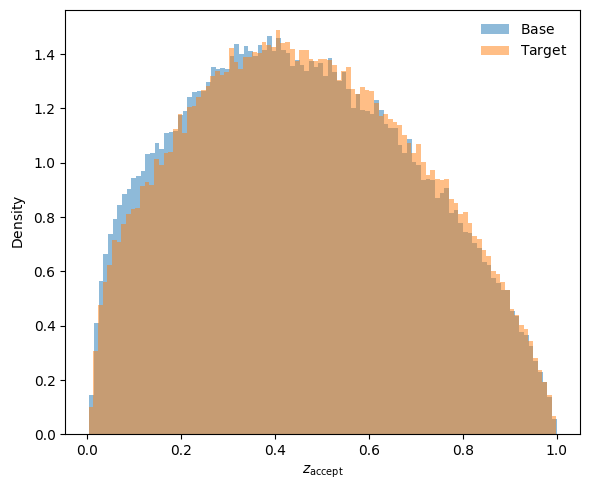

In [4]:
# Histrogram accepted z-values across all events
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.hist(pgun_accept_reject_target[:,:,5][pgun_accept_reject_target[:,:,5] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Base}$")
ax.hist(pgun_accept_reject_base[:,:,5][pgun_accept_reject_base[:,:,5] > 0.0], 100, alpha = 0.5, density = True, label = r"$\mathrm{Target}$")
ax.set_xlabel(r'$z_{\mathrm{accept}}$')
ax.set_ylabel(r'$\mathrm{Density}$')
ax.legend(frameon = False)
fig.tight_layout()

In [5]:
particles_old, counts_old = np.unique(np.abs(pgun_accept_reject_base[0,:50,0]), return_counts=True)
particles_new, counts_new = np.unique(np.abs(pgun_accept_reject_base[0,:50,1]), return_counts=True)
particles_old = np.array([int(p) for p in particles_old])
particles_new = np.array([int(p) for p in particles_new])

sorted_indices = np.argsort(particles_new)
particles_new = particles_new[sorted_indices]
counts_new = counts_new[sorted_indices]

sorted_indices = np.argsort(particles_old)
particles_old = particles_old[sorted_indices]
counts_old = counts_old[sorted_indices]


ids_old = np.abs(pgun_accept_reject_base[:,:,0][pgun_accept_reject_base[:,:,5] > 0.0])
ids_new = np.abs(pgun_accept_reject_base[:,:,1][pgun_accept_reject_base[:,:,5] > 0.0])
print(ids_new.shape)
particles_new, counts_new = np.unique(ids_new, return_counts=True)
# particles = np.array(unique_values,dtype=int)
particles_new = [int(p) for p in particles_new]
print(particles_new)
print(counts_new)

print(ids_old.shape)
particles_old, counts_old = np.unique(ids_old, return_counts=True)
# particles = np.array(unique_values,dtype=int)
particles_old = [int(p) for p in particles_old]
print(particles_old)
print(counts_old)




(197024,)
[1, 2, 3, 1103, 2101, 2103, 2203, 3101, 3103, 3201, 3203, 3303]
[83930 81201 18332   657  8409   683   709  1363   129  1483   112    16]
(197024,)
[1, 2, 3, 1103, 2101, 2103, 2203, 3101, 3103, 3201, 3203, 3303]
[ 69862 100710  15038    531   7145    556    596   1132     97   1252
     92     13]


In [6]:

# Collect multiplicity data
mult_base = np.array([len(pgun_hadrons_base[i,:][np.abs(pgun_hadrons_base[i,:,0]) > 0.0]) for i in range(Nevent)])
mult_target = np.array([len(pgun_hadrons_target[i,:][np.abs(pgun_hadrons_target[i,:,0]) > 0.0]) for i in range(Nevent)])

3.0 23.0


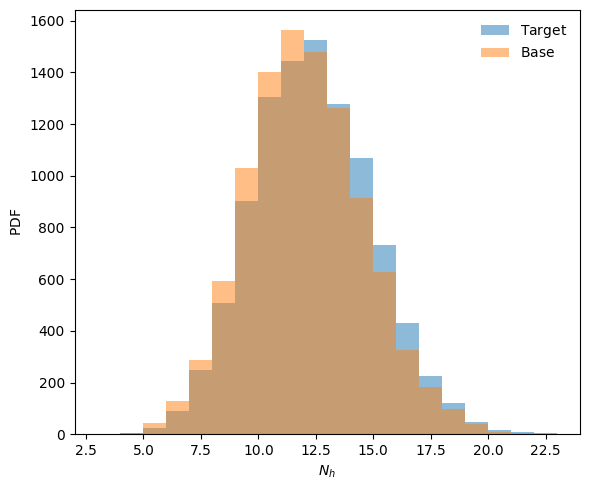

In [7]:
# Histrogram hadron multiplicity
fig, ax = plt.subplots(1,1,figsize=(6,5))

_, bins_target = np.histogram(mult_target)
_, bins_base = np.histogram(mult_base)

min_target, max_target = bins_target[0], bins_target[-1]
min_base, max_base = bins_base[0], bins_base[-1]

print(min_target, max_target)
#print(min_monash_prime, max_monash_prime)

min = np.min([min_target, min_base])
max = np.max([max_target, max_base])

bins = np.linspace(min, max, int((max - min)+1))

counts, _, _ = ax.hist(mult_target, bins, alpha = 0.5, density = False, label = r'$\mathrm{Target}$')# $(a = 0.68, b = 0.98)$')
ax.hist(mult_base, bins = bins, alpha = 0.5, density = False, label = r"$\mathrm{Base}$")
ax.set_xlabel(r'$N_h$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.legend(frameon = False)
fig.tight_layout()

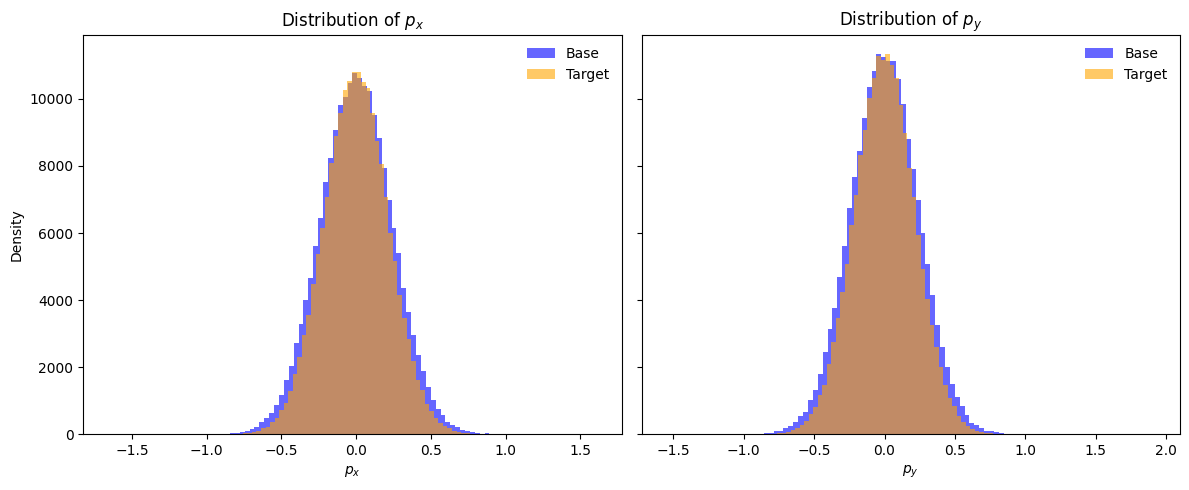

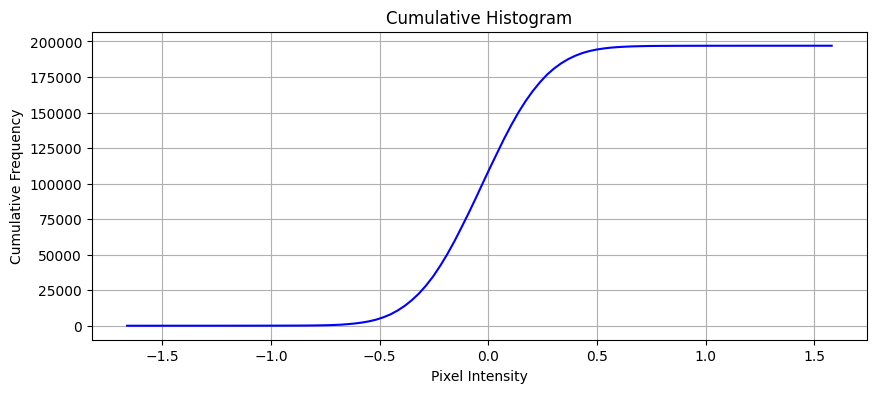

In [8]:
import matplotlib.pyplot as plt

# Apply masks
mask_base = pgun_accept_reject_base[:, :, 5] > 0.0
mask_target = pgun_accept_reject_target[:, :, 5] > 0.0

# Extract px and py
px_base = pgun_accept_reject_base[:, :, 3][mask_base]
py_base = pgun_accept_reject_base[:, :, 4][mask_base]

px_target = pgun_accept_reject_target[:, :, 3][mask_target]
py_target = pgun_accept_reject_target[:, :, 4][mask_target]

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Histogram for px
axs[0].hist(px_base, bins=100, density=False, alpha=0.6, label='Base', color='blue')
axs[0].hist(px_target, bins=100, density=False, alpha=0.6, label='Target', color='orange')
axs[0].set_xlabel(r'$p_x$')
axs[0].set_ylabel('Density')
axs[0].set_title('Distribution of $p_x$')
axs[0].legend(frameon=False)

# Histogram for py
axs[1].hist(py_base, bins=100, density=False, alpha=0.6, label='Base', color='blue')
axs[1].hist(py_target, bins=100, density=False, alpha=0.6, label='Target', color='orange')
axs[1].set_xlabel(r'$p_y$')
axs[1].set_title('Distribution of $p_y$')
axs[1].legend(frameon=False)

fig.tight_layout()
plt.show()



# Compute histogram
hist, bin_edges = np.histogram(px_base, bins=100, range=(np.min(px_base), np.max(px_base)))

# Compute cumulative histogram
cumulative_hist = np.cumsum(hist)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(bin_edges[:-1], cumulative_hist, color='blue')
plt.title('Cumulative Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Frequency')
plt.grid(True)
plt.show()


In [9]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import kstest, rayleigh

# sigma = 3.0
# x = np.random.normal(0, sigma, size=100000)
# y = np.random.normal(0, sigma, size=100000)

# r_squared = x**2 + y**2
# r = np.sqrt(r_squared)

# plt.hist(r, bins=100, density=True, alpha=0.6, label='Sampled')
# from scipy.stats import rayleigh
# x_vals = np.linspace(0, 14, 200)
# y = rayleigh(loc=0,scale=sigma).rvs(1000)
# plt.hist(y,bins=100, label='Rayleigh PDF')
# plt.legend()
# plt.title("Rayleigh distribution of radius")
# plt.show()

# ks_stat, p_value = kstest(y, 'rayleigh', args=(sigma,))
# print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")

# # Then perform KS test
# ks_stat, p_value = kstest(y, 'rayleigh', args=(0, sigma))  
# # args=(loc, scale) --> loc=0, scale=sigma
# print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")

(1000,)
(191589,)
KS statistic: 0.0152, p-value: 0.9724
KS statistic: 0.0506, p-value: 0.0000
KS statistic: 0.0092, p-value: 0.0000


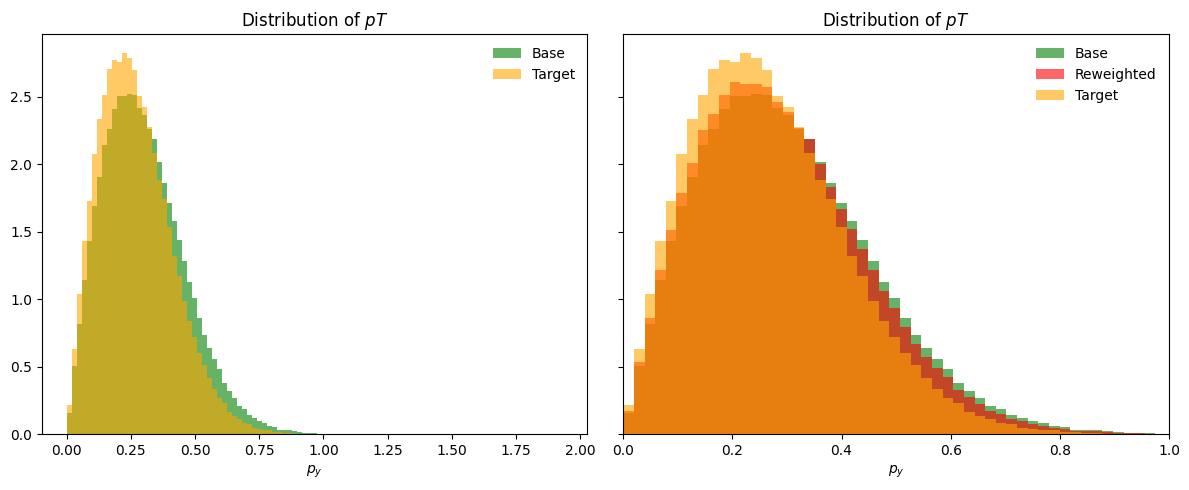

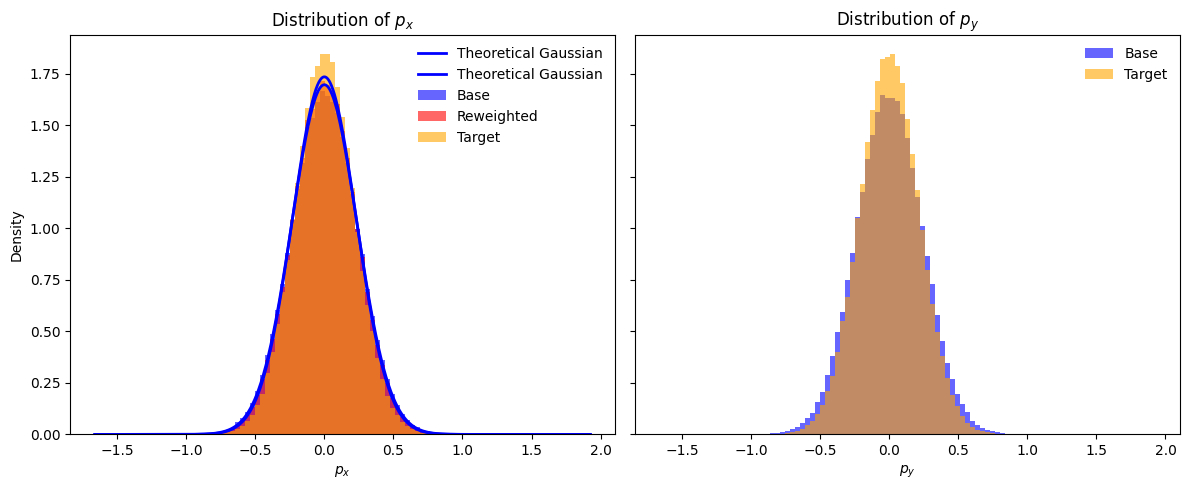

In [10]:
from scipy.stats import kstest, rayleigh


def sigma_weights( px, py, p_mask, sigma_base, sigma_target):
    weights = torch.ones(px.shape, dtype=px.dtype)
    px, py = px[p_mask], py[p_mask]
    kappa = (torch.pow(px,2) + torch.pow(py,2))/(2 * torch.pow(sigma_base, 2))
    # kappa = (torch.pow(px,2) + torch.pow(py,2))/(2)
    ratio = torch.pow(sigma_base,2)/torch.pow(sigma_target,2)
    weights[p_mask] = ratio * torch.exp(-kappa * (ratio-1))
    return weights

# Extract px and py
px_base = torch.tensor(pgun_accept_reject_base[:, :, 3][mask_base])
# px_base = torch.pow(torch.tensor(pgun_accept_reject_base[:, :, 3][mask_base]),2)

py_base = torch.tensor(pgun_accept_reject_base[:, :, 4][mask_base])
# py_base = torch.pow(torch.tensor(pgun_accept_reject_base[:, :, 4][mask_base]),2)
# px_target = torch.tensor(pgun_accept_reject_base[:, :, 3][mask_base])
# py_target = torch.tensor(pgun_accept_reject_base[:, :, 4][mask_base])

px_target = torch.tensor(pgun_accept_reject_target[:, :, 3][mask_target])
py_target = torch.tensor(pgun_accept_reject_target[:, :, 4][mask_target])
# px_base = torch.tensor(pgun_accept_reject_target[:, :, 3][mask_target])
# py_base = torch.tensor(pgun_accept_reject_target[:, :, 4][mask_target])

p_base_mask = px_base != 0

sigma_base = torch.tensor(0.335)/np.sqrt(2.)
sigma_target = torch.tensor(0.325)/np.sqrt(2.)
# sigma_target = torch.tensor(0.3)
# sigma_base = torch.tensor(0.335)

ws = sigma_weights(px_base, py_base, p_base_mask, sigma_base, sigma_target)
# ws = torch.pow(ws,2)
# print(ws)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
pT_base = torch.pow(torch.pow(px_base,2) + torch.pow(py_base,2), 1/2)
# pT_base = torch.pow(torch.pow(px_base,2) + torch.pow(py_base,2), 1)
pT_target = torch.pow(torch.pow(px_target,2) + torch.pow(py_target,2), 1/2)



# l = len(px_base)
# px_target = np.random.normal(0, sigma_target, l)
# px_target = sigma_target * np.random.normal(0, 1, l)
# py_target = np.random.normal(0, sigma_target, l)
# py_target = sigma_target * np.random.normal(0, 1, l)
# print(Nevent)

# # Compute transverse momentum pT
# pT_target = np.sqrt(px_target**2 + py_target**2)

# px_base = np.random.normal(0, sigma_base, l)
# px_base = sigma_base * np.random.normal(0, 1, l)
# py_base = np.random.normal(0, sigma_base, l)
# py_base = sigma_base * np.random.normal(0, 1, l)
# print(Nevent)

# # Compute transverse momentum pT
# pT_base = np.sqrt(px_base**2 + py_base**2)
# # pT_target = torch.pow(torch.pow(px_target,2) + torch.pow(py_target,2), 1)

data = np.random.rayleigh(scale=1.0, size=1000) 
print(np.shape(data))
print(np.shape(pT_target.numpy()))
ks_stat, p_value = kstest(data, 'rayleigh', args=(0,1.0))
print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")
ks_stat, p_value = kstest(pT_target.numpy(), 'rayleigh', args=(0,sigma_target))
print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")

ks_stat, p_value = kstest(pT_base.numpy(), 'rayleigh', args=(0,sigma_base))
print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")


_, bins_target = np.histogram(pT_target)
_, bins_base = np.histogram(pT_base)

min_target, max_target = bins_target[0], bins_target[-1]
min_base, max_base = bins_base[0], bins_base[-1]

min = np.min([min_target, min_base])
max = np.max([max_target, max_base])

bins = np.linspace(min, max, 100)


density = True
# Histogram for py
axs[0].hist(pT_base, bins=bins, density=density, alpha=0.6, label='Base', color='green')
# axs[0].hist(pT_base, weights=ws, bins=100, density=density, alpha=0.6, label='Reweighted', color='red')
axs[0].hist(pT_target, bins=bins, density=density, alpha=0.6, label='Target', color='orange')
axs[0].set_xlabel(r'$p_y$')
axs[0].set_title('Distribution of $pT$')
axs[0].legend(frameon=False)

axs[1].hist(pT_base, bins=bins, density=density, alpha=0.6, label='Base', color='green')
axs[1].hist(pT_base, weights=ws, bins=bins, density=density, alpha=0.6, label='Reweighted', color='red')
axs[1].hist(pT_target, bins=bins, density=density, alpha=0.6, label='Target', color='orange')
axs[1].set_xlabel(r'$p_y$')
axs[1].set_title('Distribution of $pT$')
axs[1].legend(frameon=False)
axs[1].set_xlim(0, 1)

fig.tight_layout()
plt.show()




_, xbins_target = np.histogram(px_target)
_, ybins_target = np.histogram(py_target)
_, xbins_base = np.histogram(px_base)
_, ybins_base = np.histogram(py_base)

xmin_target, xmax_target = xbins_target[0], xbins_target[-1]
ymin_target, ymax_target = ybins_target[0], ybins_target[-1]
xmin_base, xmax_base = xbins_base[0], xbins_base[-1]
ymin_base, ymax_base = ybins_base[0], ybins_base[-1]

min = np.min([xmin_target, xmin_base, ymin_target, ymin_base])
max = np.max([xmax_target, xmax_base, ymax_target, ymax_base])

bins = np.linspace(min, max, 100)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

from scipy.stats import norm
x = np.linspace(min, max, 1000)
pdf = norm.pdf(x, 0, sigma_target)
axs[0].plot(x, pdf, 'b-', linewidth=2, label='Theoretical Gaussian')
pdf_base = norm.pdf(x, 0, 0.235)
axs[0].plot(x, pdf_base, 'b-', linewidth=2, label='Theoretical Gaussian')




# Histogram for px
density=True
px_hist = axs[0].hist(px_base, bins=bins, density=density, alpha=0.6, label='Base', color='blue')
axs[0].hist(px_base, weights=ws, bins=bins, density=density, alpha=0.6, label='Reweighted', color='red')
axs[0].hist(px_target, bins=bins, density=density, alpha=0.6, label='Target', color='orange')
axs[0].set_xlabel(r'$p_x$')
axs[0].set_ylabel('Density')
axs[0].set_title('Distribution of $p_x$')
axs[0].legend(frameon=False)

# Histogram for py
axs[1].hist(py_base, bins=bins, density=density, alpha=0.6, label='Base', color='blue')
axs[1].hist(py_target, bins=bins, density=density, alpha=0.6, label='Target', color='orange')
axs[1].set_xlabel(r'$p_y$')
axs[1].set_title('Distribution of $p_y$')
axs[1].legend(frameon=False)

fig.tight_layout()
plt.show()




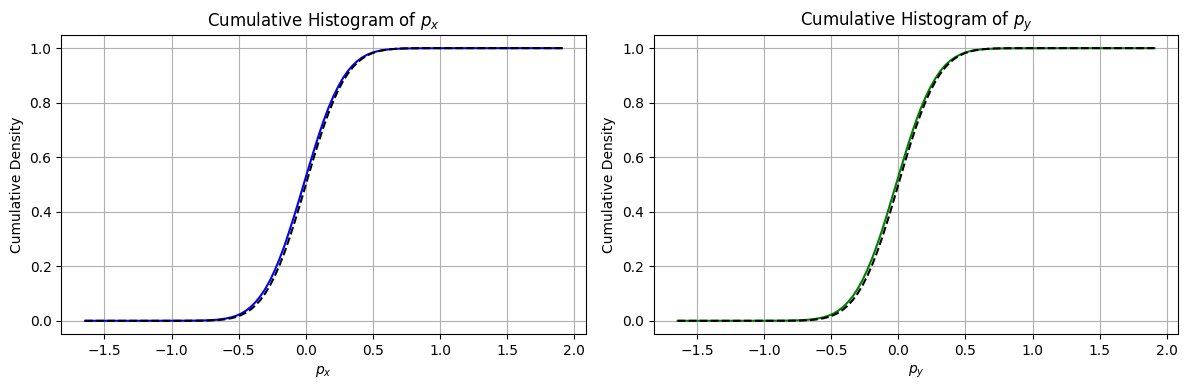

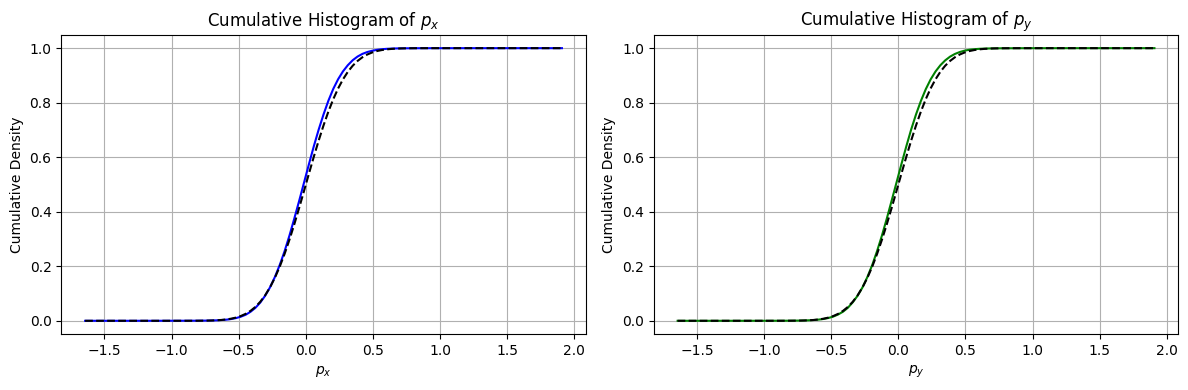

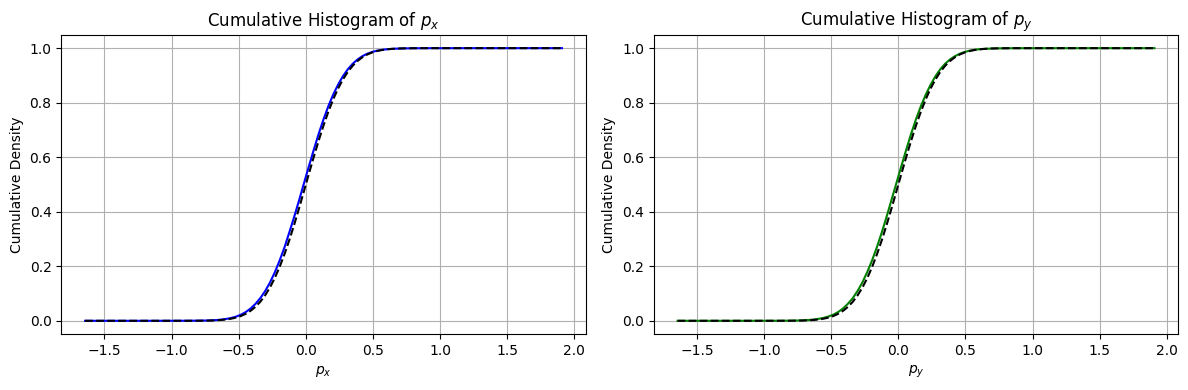

In [11]:
from scipy.stats import norm

# Extract px and py
px_base = torch.tensor(pgun_accept_reject_base[:, :, 3][mask_base])
py_base = torch.tensor(pgun_accept_reject_base[:, :, 4][mask_base])

px_target = torch.tensor(pgun_accept_reject_target[:, :, 3][mask_target])
py_target = torch.tensor(pgun_accept_reject_target[:, :, 4][mask_target])


sigma_base = torch.tensor(0.335)/np.sqrt(2.)
sigma_target = torch.tensor(0.325)/np.sqrt(2.)

ws = sigma_weights(px_base, py_base, p_base_mask, sigma_base, sigma_target)

# Assuming `px_base`, `py_base`, `bins`, and `density` are already defined
# Compute histogram and cumulative for px_base
px_hist, px_bin_edges = np.histogram(px_base, bins=bins, density=density)
px_cum = np.cumsum(px_hist)
px_cum /= px_cum[-1]  # Normalize to [0,1]
px_bin_centers = 0.5 * (px_bin_edges[:-1] + px_bin_edges[1:])

# Compute histogram and cumulative for py_base
py_hist, py_bin_edges = np.histogram(py_base, bins=bins, density=density)
py_cum = np.cumsum(py_hist)
py_cum /= py_cum[-1]  # Normalize to [0,1]
py_bin_centers = 0.5 * (py_bin_edges[:-1] + py_bin_edges[1:])

# Plot both cumulative histograms side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Evaluate Gaussian CDF at bin centers
px_base_th = norm.cdf(px_bin_centers, loc=0, scale=sigma_base)
py_base_th = norm.cdf(py_bin_centers, loc=0, scale=sigma_base)

px_target_th = norm.cdf(px_bin_centers, loc=0, scale=sigma_target)
py_target_th = norm.cdf(py_bin_centers, loc=0, scale=sigma_target)

# Subplot 1: px_base cumulative
axs[0].plot(px_bin_centers, px_cum, color='blue')
axs[0].plot(px_bin_centers, px_base_th, 'k--', label='Gaussian CDF')
axs[0].set_title('Cumulative Histogram of $p_x$')
axs[0].set_xlabel(r'$p_x$')
axs[0].set_ylabel('Cumulative Density')
axs[0].grid(True)

# Subplot 2: py_base cumulative
axs[1].plot(py_bin_centers, py_cum, color='green')
axs[1].plot(py_bin_centers, py_base_th, 'k--', label='Gaussian CDF')
axs[1].set_title('Cumulative Histogram of $p_y$')
axs[1].set_xlabel(r'$p_y$')
axs[1].set_ylabel('Cumulative Density')
axs[1].grid(True)

fig.tight_layout()
plt.show()

# Assuming `px_base`, `py_base`, `bins`, and `density` are already defined
# Compute histogram and cumulative for px_base
px_hist, px_bin_edges = np.histogram(px_target, bins=bins, density=density)
px_cum = np.cumsum(px_hist)
px_cum /= px_cum[-1]  # Normalize to [0,1]
px_bin_centers = 0.5 * (px_bin_edges[:-1] + px_bin_edges[1:])

# Compute histogram and cumulative for py_base
py_hist, py_bin_edges = np.histogram(py_target, bins=bins, density=density)
py_cum = np.cumsum(py_hist)
py_cum /= py_cum[-1]  # Normalize to [0,1]
py_bin_centers = 0.5 * (py_bin_edges[:-1] + py_bin_edges[1:])

# Plot both cumulative histograms side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Subplot 1: px_base cumulative
axs[0].plot(px_bin_centers, px_cum, color='blue')
axs[0].plot(px_bin_centers, px_target_th, 'k--', label='Gaussian CDF')
axs[0].set_title('Cumulative Histogram of $p_x$')
axs[0].set_xlabel(r'$p_x$')
axs[0].set_ylabel('Cumulative Density')
axs[0].grid(True)

# Subplot 2: py_base cumulative
axs[1].plot(py_bin_centers, py_cum, color='green')
axs[1].plot(py_bin_centers, py_target_th, 'k--', label='Gaussian CDF')
axs[1].set_title('Cumulative Histogram of $p_y$')
axs[1].set_xlabel(r'$p_y$')
axs[1].set_ylabel('Cumulative Density')
axs[1].grid(True)

fig.tight_layout()
plt.show()

# Assuming `px_base`, `py_base`, `bins`, and `density` are already defined
# Compute histogram and cumulative for px_base
px_hist, px_bin_edges = np.histogram(px_base, weights=ws, bins=bins, density=density)
px_cum = np.cumsum(px_hist)
px_cum /= px_cum[-1]  # Normalize to [0,1]
px_bin_centers = 0.5 * (px_bin_edges[:-1] + px_bin_edges[1:])

# Compute histogram and cumulative for py_base
py_hist, py_bin_edges = np.histogram(py_base, weights=ws, bins=bins, density=density)
py_cum = np.cumsum(py_hist)
py_cum /= py_cum[-1]  # Normalize to [0,1]
py_bin_centers = 0.5 * (py_bin_edges[:-1] + py_bin_edges[1:])

# Plot both cumulative histograms side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Subplot 1: px_base cumulative
axs[0].plot(px_bin_centers, px_cum, color='blue')
axs[0].plot(px_bin_centers, px_target_th, 'k--', label='Gaussian CDF')
axs[0].set_title('Cumulative Histogram of $p_x$')
axs[0].set_xlabel(r'$p_x$')
axs[0].set_ylabel('Cumulative Density')
axs[0].grid(True)

# Subplot 2: py_base cumulative
axs[1].plot(py_bin_centers, py_cum, color='green')
axs[1].plot(py_bin_centers, py_target_th, 'k--', label='Gaussian CDF')
axs[1].set_title('Cumulative Histogram of $p_y$')
axs[1].set_xlabel(r'$p_y$')
axs[1].set_ylabel('Cumulative Density')
axs[1].grid(True)

fig.tight_layout()
plt.show()

In [12]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import rayleigh



# pt_base      = np.sqrt(px_base**2 + py_base**2)
# pt_target      = np.sqrt(px_target**2 + py_target**2)
# pt_reweighted = pt_base   # same values, but we’ll histogram with weights=ws


# bins = np.linspace(0, pt_base.max(), 50)  # for example
# bin_centers = 0.5*(bins[:-1] + bins[1:])
# bin_widths  = np.diff(bins)

# obs_base, _      = np.histogram(pt_base,       bins=bins)
# obs_target, _      = np.histogram(pt_target,       bins=bins)
# obs_reweighted, _ = np.histogram(pt_reweighted, bins=bins, weights=ws)

# # PDF at each bin‐center
# pdf_base_th = rayleigh.pdf(bin_centers, scale=sigma_base)
# pdf_target_th = rayleigh.pdf(bin_centers, scale=sigma_target)

# # Expected counts = pdf * bin_width * total_entries
# N = len(pt_base)
# exp_counts_base = pdf_base_th * bin_widths * N
# exp_counts_target = pdf_target_th * bin_widths * N

# diff_base       = obs_base       - exp_counts_base
# diff_reweighted = obs_reweighted - exp_counts_target
# diff_target = obs_target - exp_counts_target

# # ————————————————————————
# # 6) Plotting the differences
# # ————————————————————————
# plt.figure(figsize=(8,4))
# plt.step(bin_centers, diff_base,       where='mid', label='Base − Theory')
# plt.step(bin_centers, diff_reweighted, where='mid', label='Reweighted − Theory')
# plt.step(bin_centers, diff_target, where='mid', label='Target − Theory')
# plt.axhline(0, color='k', lw=0.8)
# plt.xlabel(r'$p_T$')
# plt.ylabel('Obs − Exp counts')
# plt.title('Binned difference vs. Rayleigh')
# plt.legend(frameon=False)
# plt.grid(True)
# plt.tight_layout()
# plt.show()


/tmp/ipykernel_277643/1954790414.py:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pt_base       = np.sqrt(px_base**2     + py_base**2)
/tmp/ipykernel_277643/1954790414.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pt_target     = np.sqrt(px_target**2   + py_target**2)


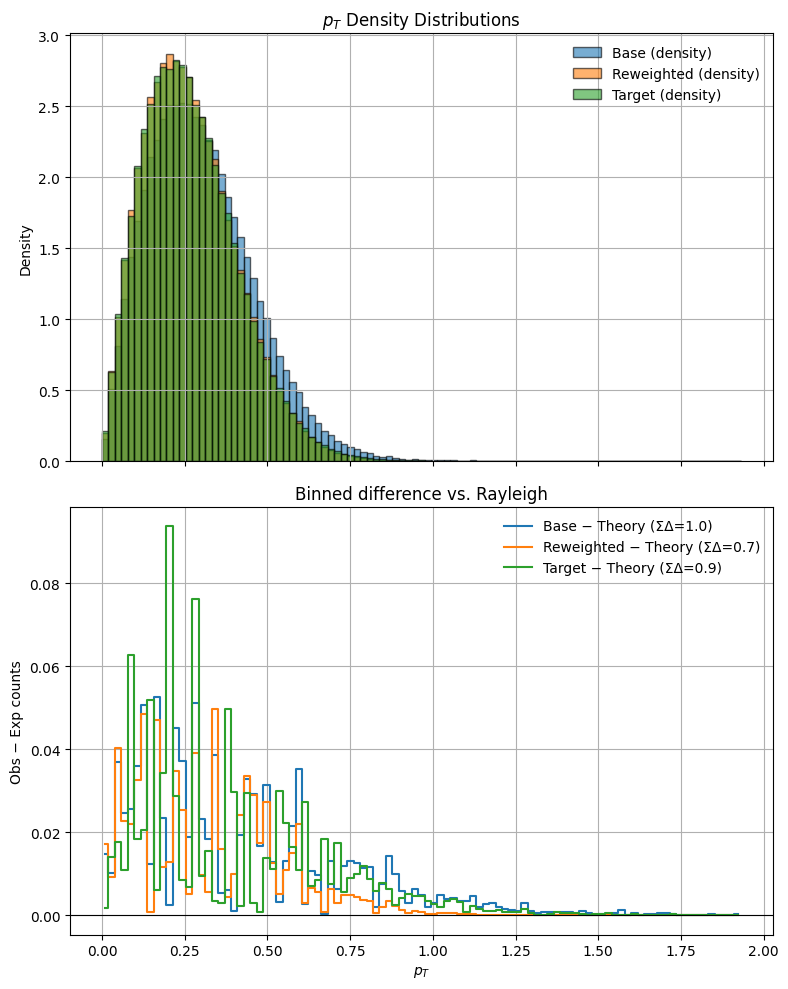

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh


# Extract px and py
px_base = torch.tensor(pgun_accept_reject_base[:, :, 3][mask_base])
py_base = torch.tensor(pgun_accept_reject_base[:, :, 4][mask_base])

px_target = torch.tensor(pgun_accept_reject_target[:, :, 3][mask_target])
py_target = torch.tensor(pgun_accept_reject_target[:, :, 4][mask_target])


sigma_base = torch.tensor(0.335)/np.sqrt(2.)
sigma_target = torch.tensor(0.3)/np.sqrt(2.)

# px_target = torch.tensor(pgun_accept_reject_base[:, :, 3][mask_base])
# py_target = torch.tensor(pgun_accept_reject_base[:, :, 4][mask_base])

# px_base = torch.tensor(pgun_accept_reject_target[:, :, 3][mask_target])
# py_base = torch.tensor(pgun_accept_reject_target[:, :, 4][mask_target])


# sigma_target = torch.tensor(0.335)/np.sqrt(2.)
# sigma_base = torch.tensor(0.3)/np.sqrt(2.)

p_base_mask = px_base != 0
ws = sigma_weights(px_base, py_base, p_base_mask, sigma_base, sigma_target)

pt_base       = np.sqrt(px_base**2     + py_base**2)
pt_target     = np.sqrt(px_target**2   + py_target**2)
pt_reweighted = pt_base   # same values, but we’ll histogram with weights=ws

bins        = np.linspace(0, pt_base.max(), 100)
bin_centers = 0.5*(bins[:-1] + bins[1:])
bin_widths  = np.diff(bins)

obs_base_dens,       _ = np.histogram(pt_base,       bins=bins, density=True)
obs_target_dens,     _ = np.histogram(pt_target,     bins=bins, density=True)
obs_reweighted_dens, _ = np.histogram(pt_reweighted, bins=bins, weights=ws, density=True)


pdf_base_th   = rayleigh.pdf(bin_centers, scale=sigma_base)
pdf_target_th = rayleigh.pdf(bin_centers, scale=sigma_target)

# N_base = len(pt_base)
# N_target = len(pt_target)
# print(N_base,N_target)

# exp_counts_base   = pdf_base_th   * bin_widths * N_base
# exp_counts_base_rew = pdf_target_th * bin_widths * N_base
# exp_counts_target = pdf_target_th * bin_widths * N_target

diff_base       = obs_base_dens       - pdf_base_th
diff_reweighted = obs_reweighted_dens - pdf_target_th
diff_target     = obs_target_dens     - pdf_target_th

diff_base = np.abs(diff_base)
diff_reweighted = np.abs(diff_reweighted)
diff_target = np.abs(diff_target)

# — compute total cumulative sums of differences
cum_base       = np.abs(diff_base).sum()
cum_reweighted = np.abs(diff_reweighted).sum()
cum_target     = np.abs(diff_target).sum()

# ————————————————————————
# 6) Plotting: histograms on top, diffs underneath with cum-sum in labels
# ————————————————————————
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# Top row: actual histograms
ax0.hist(pt_base,       bins=bins, density=True, alpha=0.6,
         label='Base (density)',       edgecolor='k')
ax0.hist(pt_reweighted, bins=bins, weights=ws, density=True, alpha=0.6,
         label='Reweighted (density)', edgecolor='k')
ax0.hist(pt_target,     bins=bins, density=True, alpha=0.6,
         label='Target (density)',     edgecolor='k')
ax0.set_ylabel('Density')
ax0.set_title(r'$p_T$ Density Distributions')
ax0.legend(frameon=False)
ax0.grid(True)

# Bottom row: Obs − Exp with cumulative sums in legend
ax1.step(bin_centers, diff_base,       where='mid',
         label=f'Base − Theory (ΣΔ={cum_base:.1f})')
ax1.step(bin_centers, diff_reweighted, where='mid',
         label=f'Reweighted − Theory (ΣΔ={cum_reweighted:.1f})')
ax1.step(bin_centers, diff_target,     where='mid',
         label=f'Target − Theory (ΣΔ={cum_target:.1f})')
ax1.axhline(0, color='k', lw=0.8)
ax1.set_xlabel(r'$p_T$')
ax1.set_ylabel('Obs − Exp counts')
ax1.set_title('Binned difference vs. Rayleigh')
ax1.legend(frameon=False)
ax1.grid(True)

plt.tight_layout()
plt.show()


The reweighting module computes a weight array, given the base $B$ and perturbed $P$ parameterizations, according to 
$$
\boldsymbol{w} = \begin{pmatrix}
    w_1 \\
    w_2 \\
    \vdots \\
    w_N
  \end{pmatrix}, \text{ where } \\
  w_n = \prod_{i = 1}^{N_{h,n}} \left(\frac{f(z^{h_i}_\text{accept}; \{a, b\}_P)}{f(z^{h_i}_\text{accept}; \{a, b\}_{B})}\right)
  \prod_{j = 1}^{n_{h_i}} \left(\frac{\hat{f} - f(z^{j, h_i}_\text{reject}; \{a, b\}_P)}{\hat{f} - f(z^{j, h_i}_\text{reject}; \{a, b\}_{B}}\right)
$$
where $\hat{f}$ is the oversampling factor associated with the sampling of $z$ (here the over-sampling factor is 10). For each event, the accepcted and rejected $z$-values as well as the transverse mass $m_T^2 = p_x^2 + p_y^2 + m^2$ of each hadron is required to compute the event weight.

In [14]:
"""
# lund_weight.py is a part of the RSA package.
# Copyright (C) 2025 RSA authors (see AUTHORS for details).
# RSA is licensed under the GNU GPL v3 or later, see LICENSE for details.
# Please respect the MCnet Guidelines, see GUIDELINES for details.
"""

import torch
from torch import nn
import numpy as np

class LundWeight(nn.Module):
    def __init__(self, params_base, params, over_sample_factor):
        super(LundWeight, self).__init__()
        """
        LundWeight class for computing event weights for the Lund fragmentation function

        Args:
            params_base (torch.Tensor): ------ Base parameters for the Lund fragmentation function
            params (torch.Tensor): ----------- Parameters to be reweighted for the Lund fragmentation function
            over_sample_factor (int): -------- Over-sampling factor for the rejected events
        """

        # Intialize the module parameters
        self.params_base = params_base
        # Initialize the params dictionary

        self.params = torch.nn.ParameterDict({})
        # Iterate of all keys in the dictionary and create a parameter for each key
        for key in params_base.keys():
            if key in params:
                self.params[key] = torch.nn.Parameter(params[key], requires_grad = True)
            else:
                self.params[key] = torch.nn.Parameter(params_base[key].clone().detach(), requires_grad = False)

        # Initialize the over-sampling factor
        self.over_sample_factor = over_sample_factor

        # Constants for numerical stability checks
        self.AFROMZERO = 0.02
        self.EXPMAX = 50.
        self.AFROMC = 0.01

    def zMaxCalc(self, a, b, c):
        """
        Estimate the maximum value of z for the Lund fragmentation function
    
        Args:
            a (torch.Tensor): --------------- Parameter a
            b (torch.Tensor): --------------- Parameter b
            c (torch.Tensor): --------------- Parameter c
        
        Returns:
            zMax (torch.Tensor): Estimate for the maximum value of z given (a,b,c)
        """
        # Normalization for Lund fragmentation function so that f <= 1.
        # Special cases for a = 0 and a = c.
        aIsZero = (a < self.AFROMZERO)
        aIsC = (torch.abs(a - c) < self.AFROMC)
        
        # Initialize zMax tensor with the same shape as inputs
        zMax = torch.zeros_like(a, dtype = a.dtype)
        
        # Handle special case where a is zero
        zero_mask = aIsZero
        zMax[zero_mask] = torch.where(c[zero_mask] > b[zero_mask], b[zero_mask] / c[zero_mask], torch.ones_like(zMax[zero_mask], dtype = a.dtype))
        
        # Handle special case where a is essentially equal to c
        c_mask = aIsC & ~zero_mask
        zMax[c_mask] = b[c_mask] / (b[c_mask] + c[c_mask])
        
        # Handle the general case
        general_mask = ~(zero_mask | c_mask)
        if general_mask.any():
            # Compute zMax for the general case
            b_sub = b[general_mask]
            c_sub = c[general_mask]
            a_sub = a[general_mask]
            
            zMax_general = 0.5 * (b_sub + c_sub - torch.sqrt(torch.pow(b_sub - c_sub, 2) + 4 * a_sub * b_sub)) / (c_sub - a_sub)
            
            # Check for NaN values
            if torch.isnan(zMax_general).any():
                print('zMax_1', zMax_general)
                print('a', a[general_mask], 'b', b[general_mask], 'c', c[general_mask])
                exit()
            
            # Adjust zMax in numerically unstable regions 
            zMax_general = torch.where((zMax_general > 0.9999) & (b_sub > 100.), torch.min(zMax_general, 1. - a_sub / b_sub), zMax_general)
            zMax[general_mask] = zMax_general
        
        return zMax

    def likelihood(self, z, mT, a, b, c, z_mask = None, mT_mask = None, a_mask = None, b_mask = None, c_mask = None):
        """
        Compute the likelihood of the Lund fragmentation function

        Args:
            z (torch.Tensor): --------------- Input tensor
            mT (torch.Tensor): -------------- Transverse mass tensor (can be different shape from z)
            a (torch.Tensor): --------------- Parameter a
            b (torch.Tensor): --------------- Parameter b
            c (torch.Tensor): --------------- Parameter c (default: torch.tensor(1., requires_grad=True))
            z_mask (torch.Tensor, optional):  Boolean mask tensor for z (default: None)
            mT_mask (torch.Tensor, optional): Boolean mask tensor for mT (default: None)
            a_mask (torch.Tensor, optional): Boolean mask tensor for a (default: None)
            b_mask (torch.Tensor, optional): Boolean mask tensor for b (default: None)
            c_mask (torch.Tensor, optional): Boolean mask tensor for c (default: None)

        Returns:
            likelihood (torch.Tensor): Computed likelihood values (shape determined by broadcasting rules)
        """
        # Determine the shape after broadcasting
        broadcast_shape = torch.broadcast_shapes(z.shape, mT.shape, a.shape, b.shape, c.shape)
        # If no masks are provided, consider all elements
        if z_mask is None:
            z_mask = torch.ones(z.shape, dtype=torch.bool, device=z.device)
        if mT_mask is None:
            mT_mask = torch.ones(mT.shape, dtype=torch.bool, device=mT.device)
        if a_mask is None:
            a_mask = torch.ones(a.shape, dtype=torch.bool, device=a.device)
        if b_mask is None:
            b_mask = torch.ones(b.shape, dtype=torch.bool, device=b.device)
        if c_mask is None:
            c_mask = torch.ones(c.shape, dtype=torch.bool, device=c.device)

        # Broadcast z, mT, and their masks to the common shape
        z_broad = z.expand(broadcast_shape)
        mT_broad = mT.expand(broadcast_shape)
        a_broad = a.expand(broadcast_shape)
        b_broad = b.expand(broadcast_shape)
        c_broad = c.expand(broadcast_shape)
        z_mask_broad = z_mask.expand(broadcast_shape)
        mT_mask_broad = mT_mask.expand(broadcast_shape)
        a_mask_broad = a_mask.expand(broadcast_shape)
        b_mask_broad = b_mask.expand(broadcast_shape)
        c_mask_broad = c_mask.expand(broadcast_shape)
    
        # Combine masks
        combined_mask = z_mask_broad & mT_mask_broad & a_mask_broad & b_mask_broad & c_mask_broad
        
        # Create a tensor to store the results, initialized with zeros
        likelihood = torch.zeros(broadcast_shape, dtype=z.dtype, device=z.device)
    
        # Only perform calculations on unmasked elements
        z_unmasked = z_broad[combined_mask]
        mT_unmasked = mT_broad[combined_mask]
        a_unmasked = a_broad[combined_mask]
        b_unmasked = b_broad[combined_mask]
        c_unmasked = c_broad[combined_mask]
    
        # Check if we have any unmasked elements to process
        if z_unmasked.numel() > 0:
            # Adjust b-parameter
            b_exp = b_unmasked * mT_unmasked
            
            # Special case for a = 0.
            aIsZero = (a_unmasked < self.AFROMZERO)
            # Determine position of maximum.
            zMax = self.zMaxCalc(a_unmasked, b_exp, c_unmasked)
            
            # Be careful of -inf values in aCoeff, z is being rounded to exactly 1.
            aCoef = torch.log(1. - z_unmasked) - torch.log(1. - zMax)
            if torch.isneginf(aCoef).any():
                print('aCoef is returning -inf value, please check that all z < 1.')
                print('aCoeff', aCoef)
    
            bCoef = (1. / zMax) - (1. / z_unmasked)
            cCoef = torch.log(zMax) - torch.log(z_unmasked)
            fExp = b_exp * bCoef + c_unmasked * cCoef

            
            # Special cases for a = 0.
            not_zero_mask = ~aIsZero
            fExp[not_zero_mask] = fExp[not_zero_mask] + a_unmasked[not_zero_mask] * aCoef[not_zero_mask]
            
            # Feed through numerical stabilizer
            fVal = torch.exp(torch.clamp(fExp, min=-self.EXPMAX, max=self.EXPMAX))
            
            # Assign computed values back to the likelihood tensor
            likelihood[combined_mask] = fVal

        return likelihood

    def sigma_weights(self, px, py, p_mask):
        weights = torch.ones(px.shape, dtype=px.dtype)
        sigma_base = torch.tensor(self.params_base['sigma'].item())/torch.sqrt(torch.tensor(2))
        sigma_target = torch.tensor(self.params['sigma'].item())/torch.sqrt(torch.tensor(2))
        px, py = px[p_mask], py[p_mask]
        kappa = (torch.pow(px,2) + torch.pow(py,2))/(2 * torch.pow(sigma_base, 2))
        ratio = torch.pow(sigma_base,2)/torch.pow(sigma_target,2)
        weights[p_mask] = ratio * torch.exp(-kappa * (ratio-1))
        # print(weights[0])
        # print('kapa: ', kappa)
        # print(sigma_base)
        # print(sigma_target)
        # print(sigma_base/sigma_target)
        # print((sigma_base/sigma_target)**2)
        # print('ratio: ', ratio)
        # print('ratio: ', -kappa * (ratio-1.))
        # print('exp: ', torch.exp(-kappa * (ratio-1)))
        # print()
        print(weights.prod(axis=1))
        print('weights: ', weights)
        print('weights: ', weights[0])

        return weights.prod(axis=1)


    
    def forward(self, z_mT2_pid, fPrel):
        """
        Forward pass of the weight module -- consists of computing the event weights for a given batch
        of training data.

        Args:
            z_mT2 (torch.Tensor): Tensor containing mT2 and z accept-reject data 
            fPrel (torch.Tensor): Tensor containing fPrel values

        Returns:
            weights (torch.Tensor): Computed event weights
        """
        batch_size = z_mT2_pid.shape[0]
        weights = torch.ones(batch_size)

        # Extract the (absolute value) pid values
        pid_old = torch.abs(z_mT2_pid[:, :, 0])
        pid_new = torch.abs(z_mT2_pid[:, :, 1])

        # Compute and create a, b, and c tensors for base and alternative parameters (This is a bottleneck, there isn't a good way to vectorize)
        a_old_base = torch.stack([torch.stack([self.params_base[f'a{int(round(pid_old[i,j].item()))}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        a_base = torch.stack([torch.stack([self.params_base[f'a{int(round(pid_new[i,j].item()))}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        b_base = torch.stack([torch.stack([self.params_base[f'b{int(round(pid_new[i,j].item()))}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        c_base = 1 + a_base - a_old_base
        temp = np.array([([f'a{int(pid_new[i,j].item())}' for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)])

        a_old_alt = torch.stack([torch.stack([self.params[f'a{int(round(pid_old[i,j].item()))}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        a_alt = torch.stack([torch.stack([self.params[f'a{int(round(pid_new[i,j].item()))}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        b_alt = torch.stack([torch.stack([self.params[f'b{int(round(pid_new[i,j].item()))}'] for j in range(z_mT2_pid.shape[1])]) for i in range(batch_size)]).view(batch_size, z_mT2_pid.shape[1], 1)
        c_alt = 1 + a_alt - a_old_alt

        # Create masks for base and alternate parameters (masks should be the same)
        a_mask = a_base != 0.
        b_mask = b_base != 0.
        c_mask = a_base != 0.

        # Extract the mT2 values 
        mT2 = torch.tensor(z_mT2_pid[:, :, 2],dtype=a_base.dtype)
        # Reshape into column tensor
        mT2 = mT2.view(mT2.shape[0], mT2.shape[1], 1)
        # Create a mask for zero values
        mT2_mask = mT2 != 0.

        # Extract the accepted z values
        z_accept = z_mT2_pid[:, :, 5]
        # Reshape into column tensor
        z_accept = z_accept.view(z_accept.shape[0], z_accept.shape[1], 1)
        # Remove any zero values
        z_accept_mask = z_accept != 0.

        # Extract the rejected z values
        z_reject = z_mT2_pid[:, :, 6:]
        # Reshape into column tensor
        z_reject = z_reject.view(z_reject.shape[0], z_reject.shape[1], z_reject.shape[2])
        # Remove any zero values along the event index
        z_reject_mask = z_reject != 0.

        # Extract the rejected fPrel values
        fPrel_reject = fPrel[:, :, 1:]
        fPrel_reject = fPrel_reject.view(fPrel_reject.shape[0], fPrel_reject.shape[1], fPrel_reject.shape[2])
        fPrel_reject_mask = fPrel_reject != 0.

        # Compute the accept and reject weights
        accept_weights = self.likelihood(z_accept, mT2, a_alt, b_alt, c_alt, z_mask = z_accept_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask) \
                         / self.likelihood(z_accept, mT2, a_base, b_base, c_base, z_mask = z_accept_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask)    
        reject_weights = ((self.over_sample_factor * (fPrel_reject * fPrel_reject_mask.masked_fill(z_accept_mask == 0, 1))) - self.likelihood(z_reject, mT2, a_alt, b_alt, c_alt, z_mask = z_reject_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask)) \
                         / ((self.over_sample_factor * (fPrel_reject * fPrel_reject_mask.masked_fill(z_accept_mask == 0, 1))) - self.likelihood(z_reject, mT2, a_base, b_base, c_base, z_mask = z_reject_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask))

        # Flatten the weights
        accept_weights = (accept_weights * z_accept_mask).masked_fill(z_accept_mask == 0, 1).prod(dim=2).prod(dim=1)
        reject_weights = (reject_weights * z_reject_mask).masked_fill(z_reject_mask == 0, 1).prod(dim=2).prod(dim=1)

        # Add weights for reweighting sigma_pT
        if self.params['sigma']:
            px, py = z_mT2_pid[:, :, 3], z_mT2_pid[:, :, 4]
            p_mask = (px != 0)
            # print(type(px),px.shape)
            weights_sigma = self.sigma_weights(px,py,p_mask)
        # print(weights_sigma.shape)
        # print(weights.shape)

        # The final event weight is the product of accepted and rejected weights
        weights = accept_weights * reject_weights
        if self.params['sigma']:
            print(weights[0:5], weights_sigma[0:5])
            weights = weights * weights_sigma
            print(weights[0:5])
    

        return weights

In [15]:
# Set base (reference) parameterization
# aLundD = 0.61
# bLundD = 1.0
# aLundU = 0.78
# bLundU = 0.88
# aLundS = 0.48
# bLundS = 1.0
# aLundDiquark = 1.65
# bLundDiquark = 1.2

aExtraDQuark = 0
aExtraUQuark = 0
aExtraSQuark = 0
aExtraCquark = 0
aExtraBquark = 0
aExtraDiquark = 0.97

bNonstandardD = 0.88
bNonstandardU = 0.88
bNonstandardS = 0.88
bNonstandardC = 0.88
bNonstandardB = 0.88
bNonstandardH = 0.88

aLund = 0.68
bLund = 0.98
sigma = 0.335

aLundD = aLund + aExtraDQuark
# bLundD = bNonstandardD
bLundD = bLund
aLundU = aLund + aExtraUQuark
# bLundU = bNonstandardU
bLundU = bLund
aLundS = aLund + aExtraSQuark
# bLundS = bNonstandardS
bLundS = bLund
aLundDiquark = aLund + aExtraDiquark
# bLundDiquark = bNonstandardH
bLundDiquark = bLund


params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0), 'sigma': torch.tensor(sigma),
               'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
               'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
               'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
               'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
               'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
               'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark)}

# Set parameters to reweigh to (alternative parameterization)
# Technically should only include the parameters that are being reweighted
#aLundD_alt = 0.61
# bLundD_alt = 0.85 # Target v1
# aLundU_alt = 0.73 # Target v1
# bLundU_alt = 0.7  # Target v1

aLund_target = 0.78
bLund_target = 0.98
sigma_alt = 0.325

# aLundD_alt = aLund_target + 0.04
# aLundU_alt = aLund_target - 0.04
# bLundD_alt = bLund_target - 0.1
# bLundU_alt = bLund_target + 0.1
aLundD_alt = aLund_target 
aLundU_alt = aLund_target
bLundD_alt = bLund_target
bLundU_alt = bLund_target

# aLundU_alt = 0.76
# aLundD_alt = 0.76
# bLundU_alt = 0.84
# bLundD_alt = 0.84

#bLundD_alt = 0.93 # Target v2
#aLundU_alt = 0.75 # Target v2
#bLundU_alt = 0.95  # Target v2
#aLundS_alt = 0.48
#bLundS_alt = 1.1
#aLundDiquark_alt = 1.65
#bLundDiquark_alt = 1.2
params_alt = {#'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
              'sigma': torch.tensor(sigma_alt),
              'a1': torch.tensor(aLundD_alt)}
            #   'a2': torch.tensor(aLundU_alt),
            #   'b1': torch.tensor(bLundD_alt),  
            #   'b2': torch.tensor(bLundU_alt)}
              #'b3': torch.tensor(bLundS_alt)}
              #'a3': torch.tensor(aLundS_alt), , 'a1103': torch.tensor(aLundDiquark_alt), 'b1103': torch.tensor(bLundDiquark_alt),
              #'a2101': torch.tensor(aLundDiquark_alt), 'b2101': torch.tensor(bLundDiquark_alt), 'a2103': torch.tensor(aLundDiquark_alt), 'b2103': torch.tensor(bLundDiquark_alt),
              #'a2203': torch.tensor(aLundDiquark_alt), 'b2203': torch.tensor(bLundDiquark_alt), 'a3101': torch.tensor(aLundDiquark_alt), 'b3101': torch.tensor(bLundDiquark_alt),
              #'a3103': torch.tensor(aLundDiquark_alt), 'b3103': torch.tensor(bLundDiquark_alt), 'a3201': torch.tensor(aLundDiquark_alt), 'b3201': torch.tensor(bLundDiquark_alt),
              #'a3203': torch.tensor(aLundDiquark_alt), 'b3203': torch.tensor(bLundDiquark_alt), 'a3303': torch.tensor(aLundDiquark_alt), 'b3303': torch.tensor(bLundDiquark_alt)}

# Set the over sample factor (for the pgun_qqbar datasets this is 10.)
over_sample_factor = 10.

print(params_alt)
# Initialize the reweighting module
reweighter = LundWeight(params_base, params_alt, over_sample_factor = over_sample_factor)

{'sigma': tensor(0.3250), 'a1': tensor(0.7800)}


In [16]:
# print(reweighter.params)

# for k,v in reweighter.params.items():
#     print(v.requires_grad)

In [17]:
# Consider a 'batch' consisting of 10,000 events

# Target
pgun_accept_reject_base_torch = torch.from_numpy(pgun_accept_reject_base[0:Nevent].copy())
pgun_fPrel_base_torch = torch.from_numpy(pgun_fPrel_base[0:Nevent].copy())



# Check for values of 1 and correct
#epsilon = 1e-10
#pgun_accept_reject_target_torch[pgun_accept_reject_target_torch == 1] -= epsilon

pgun_mult_base_torch = torch.from_numpy(mult_base[0:Nevent].copy())
pgun_mult_base_torch = torch.reshape(pgun_mult_base_torch, (Nevent,1))

In [18]:
# Check the shapes
print(pgun_accept_reject_base_torch.shape)
print(pgun_fPrel_base_torch.shape)
print(pgun_mult_base_torch.shape)

print(torch.tensor(((0.335/0.325)**2),dtype=torch.float64))

torch.Size([10000, 250, 105])
torch.Size([10000, 250, 100])
torch.Size([10000, 1])
tensor(1.0625, dtype=torch.float64)


In [19]:
# Compute the weight array
weights = reweighter.forward(pgun_accept_reject_base_torch, pgun_fPrel_base_torch)
weights = weights.detach().numpy()
# print(type(weights))

# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_a{aLundU_alt}_b{bLundD_alt}_N{Nevent}.npy'
weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/aD{aLund:.2}_aU{aLund:.2}_bD{bLund:.2}_bU{bLund:.2}_to_aD{aLundD_alt:.2}_aU{aLundU_alt:.2}_bD{bLundD_alt:.2}_bU{bLundU_alt:.2}_N{Nevent}.npy'
# np.save(weights_path ,weights)

/tmp/ipykernel_277643/1818593790.py:248: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mT2 = torch.tensor(z_mT2_pid[:, :, 2],dtype=a_base.dtype)


tensor([0.4922, 0.5595, 1.1173,  ..., 1.2459, 1.2322, 1.0420],
       dtype=torch.float64)
weights:  tensor([[1.0366, 0.8696, 0.9083,  ..., 1.0000, 1.0000, 1.0000],
        [0.8397, 1.0212, 0.9751,  ..., 1.0000, 1.0000, 1.0000],
        [1.0597, 1.0389, 1.0412,  ..., 1.0000, 1.0000, 1.0000],
        ...,
        [1.0608, 1.0612, 1.0480,  ..., 1.0000, 1.0000, 1.0000],
        [1.0603, 1.0486, 0.9498,  ..., 1.0000, 1.0000, 1.0000],
        [1.0563, 1.0226, 1.0217,  ..., 1.0000, 1.0000, 1.0000]],
       dtype=torch.float64)
weights:  tensor([1.0366, 0.8696, 0.9083, 0.8258, 1.0541, 0.9242, 0.9810, 1.0498, 1.0249,
        1.0211, 1.0060, 0.9513, 1.0277, 0.9519, 0.8706, 0.9973, 1.0279, 1.0158,
        1.0508, 1.0337, 1.0485, 0.8290, 1.0420, 0.8304, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,

In [20]:
# aLund = 0.72
# bLund = 0.88
# aLundU_alt = 0.68
# bLundU_alt = 0.98
# aLund = 0.68
# bLund = 0.98
# aLundU_alt = 0.72
# bLundU_alt = 0.88

# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_a{aLundU_alt}_b{bLundD_alt}_N{nevents}.npy'
# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_aD{aLundD_alt}_bD{bLundU_alt}_aU{aLundU_alt}_bU{bLundU_alt}_N{nevents}.npy'
# np.save(weights_path ,weights)

# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_a{aLundU_alt}_b{bLundU_alt}_N{nevents}.npy'
# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_aD0.15_bD0.68_b{bLund}_to_a{aLundU_alt}_b{bLundU_alt}_N{nevents}.npy'
# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_aD{aLundD_alt}_bD{bLundU_alt}_aU{aLundU_alt}_bU{bLundU_alt}_N{nevents}.npy'
# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/aD{aLund}_aU{aLund}_bD{bLund}_bU{bLund}_to_aD{aLundD_alt}_aU{aLundU_alt}_bD{bLundD_alt}_bU{bLundU_alt}_N{Nevent}.npy'
# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/aD{aLund:.2}_aU{aLund:.2}_bD{bLund:.2}_bU{bLund:.2}_to_aD{aLundD_alt:.2}_aU{aLundU_alt:.2}_bD{bLundD_alt:.2}_bU{bLundU_alt:.2}_N{Nevent}.npy'

# weights_loaded = np.load(weights_path)
weights_loaded = weights

In [21]:
# Compute the reweighting metrics (Target v1)
# print(weights_loaded.detach().numpy().shape)
# print(weights_loaded.detach().numpy())
one_minus_mu = 1. - np.sum(weights_loaded) / len(weights_loaded)
sigma_one_minus_mu = abs(1. - np.sqrt((np.sum(weights_loaded**2)/len(weights_loaded) - (np.sum(weights_loaded)/len(weights_loaded))**2)*len(weights_loaded)/(len(weights_loaded) - 1)))/np.sqrt(len(weights_loaded))
Neff = (np.sum(weights_loaded)**2 / np.sum(weights_loaded**2)) / len(weights_loaded)
print('1 - mu:', one_minus_mu, '+/-', sigma_one_minus_mu)
print('Neff:', Neff)

1 - mu: 0.037683859018413424 +/- 0.004954811897959163
Neff: 0.7844137916397744


In [22]:
# plt.figure()
# # # print(type(mult_base[0:Nevent]))
# data_target = mult_target[0:Nevent]
# data_base = mult_base[0:Nevent]

# # # print(len(data_target))
# # # weights_loaded
# # = weights_loaded
# #.detach().numpy()

# # # Compute histogram and weighted errors
# hist_vals_target, bin_edges_target = np.histogram(data_target, bins=bins)
# bin_centers_target = 0.5 * (bin_edges_target[:-1] + bin_edges_target[1:])  # Compute bin centers

# # # Compute errors (square root of sum of squared weights_loaded
# # in each bin)
# sum_all_weights_loaded = np.sum(weights_loaded)
# errors_target = np.sqrt(hist_vals_target)
# hist_weights_loaded, _ = np.histogram(data_base, bins=bins, weights=weights_loaded**2)
# hist_wbase, _ = np.histogram(data_base, bins= bins, weights=weights_loaded)
# errors_model = np.sqrt(hist_weights_loaded)

# # hist_squared_weights_loaded
# #, _ = np.histogram(data_target, bins=bins, weights_loaded
# #=weights_loaded
# #**2)
# # # # print((hist_squared_weights_loaded
# #)/sum_all_weights_loaded
# #**2 )
# # # # print(hist_weights_loaded
# #**2/sum_all_weights_loaded
# #**4 * np.sum(weights_loaded
# #**2))
# # errors_target = np.sqrt((hist_squared_weights_loaded
# #)/sum_all_weights_loaded
# #**2 + hist_weights_loaded
# #**2/sum_all_weights_loaded
# #**4 * np.sum(weights_loaded
# #**2))plt.errorbar(bin_centers_target, hist_weights_loaded
# #, yerr=errors_target, fmt=".", color="black", label="Error Bars")
# plt.errorbar(bin_centers_target, hist_vals_target, yerr=errors_target, fmt=".", color="black", label="target")
# plt.errorbar(bin_centers_target, hist_wbase, yerr=errors_model, fmt=".", color="red", label="reweighted")
# # plt.errorbar(bin_centers_target, hist_weights_loaded
# #, yerr=errors_model, fmt=".", color="blue", label="Error Bars")
# plt.legend()


# # Check the reweighed multiplicity historgram
# fig, ax = plt.subplots(1,1,figsize=(7,5))

# # ax.hist(mult_target[0:Nevent], bins = bins, alpha = 0.5, label = r"$\mathrm{Target}$"+ rf"$(au = {aLundU_alt:.}, ad = {aLundD_alt}, bu = {bLundU_alt}, bd = {bLundD_alt})$", color = 'tab:orange', density = True)
# # ax.hist(mult_target[0:Nevent], bins=bins, alpha=0.5, 
# #         label=rf"$\mathrm{{Target}}$" + 
# #               rf"$(au = {aLundU_alt:.2f}, ad = {aLundD_alt:.2f}, " + 
# #               rf"bu = {bLundU_alt:.2f}, bd = {bLundD_alt:.2f})$", 
# #         color='tab:orange', density=True)
# ax.hist(mult_target[0:Nevent], bins=bins, alpha=0.5, 
#         label=rf"$\mathrm{{Target}}$" + 
#               r"$(\sigma_{p^T} =$"+f" {sigma_alt})", 
#         color='tab:orange', density=True)
# # ax.hist(mult_base[0:Nevent], bins = bins, alpha = 0.5, label = r'$\mathrm{Base}$' + rf'$(au = ad = {aLund}, bu = bd = {bLund})$', color = 'tab:blue', density = True)
# ax.hist(mult_base[0:Nevent], bins = bins, alpha = 0.5, label = r'$\mathrm{Base}$' + r'$(\sigma_{p^T} =$'+f' {sigma})', color = 'tab:blue', density = True)
# ax.hist(mult_base[0:Nevent], bins = bins, weights = weights_loaded, alpha = 0.5, label = r"$\mathrm{Reweighed}$", color = 'tab:green', density = True)

# # ax.errorbar(bin_centers_target, hist_vals_target, yerr=errors_target, fmt=".", color="black", label="Error Bars")


# # Place the rewighting metrics on the upper left corner of the figure
# ax.text(0.05, 0.9, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10, transform = ax.transAxes)
# ax.text(0.05, 0.85, rf'$1 - \mu = {one_minus_mu:3f}$', fontsize = 10, transform = ax.transAxes)

# #ax.text(1.0, 0.10, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10)
# #ax.text(1.0, 0.10, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10)
# #ax.text(1.0, 0.095, rf'$1 - \mu = {one_minus_mu:3f}$', fontsize = 10)

# ax.set_xlabel(r'$N_h$')
# ax.set_ylabel(r'$\mathrm{PDF}$')
# ax.legend(frameon = False, fontsize = 'small')
# ax.set_title(r'$\mathrm{Posthoc}$')
# fig.tight_layout()
# # plt.savefig('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/reweighting_sigma/' + f'{}')

# # print(hist_vals)
# # print(hist_vals_target)

In [23]:
import torch
import ot

class WassersteinLoss(torch.nn.Module):
    def __init__(self, p):
        super(WassersteinLoss, self).__init__()
        """
        Compute the one-dimensional Wasserstein distance between two input tensors x and y with weights x_weights and y_weights

        Args:
            p (int): Order of the Wasserstein distance

        Returns:
            (torch.tensor): One-dimensional Wasserstein distance
        """
        self.p = p

    def forward(self, x, y, x_weights = None, y_weights = None):
        """
        Compute the one-dimensional Wasserstein distance between two input tensors x and y
        with x weighted by x_weights
        """
        # The weights must be normalized for the Wasserstein loss
        x_weights = x_weights / torch.sum(x_weights)
        y_weights = torch.ones(y.shape[0]) / y.shape[0]
        # Compute the Wasserstein distance
        return ot.wasserstein_1d(x, y, u_weights = x_weights, v_weights = y_weights, p = self.p)

3.0 23.0
<class 'torch.Tensor'> <class 'torch.Tensor'>


/pscratch/sd/l/ljpuslar/.conda/envs/RSA_env/lib/python3.13/site-packages/ot/lp/solver_1d.py:41: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3725.)
  cws = cws.T.contiguous()
/tmp/ipykernel_277643/3748524526.py:53: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax_main.text(0.05, 0.8, rf'$log(loss) = {np.log10(loss):.7f}$', fontsize=10, transform=ax_main.transAxes)
/tmp/ipykernel_277643/3748524526.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


tensor(0.0400, dtype=torch.float64)


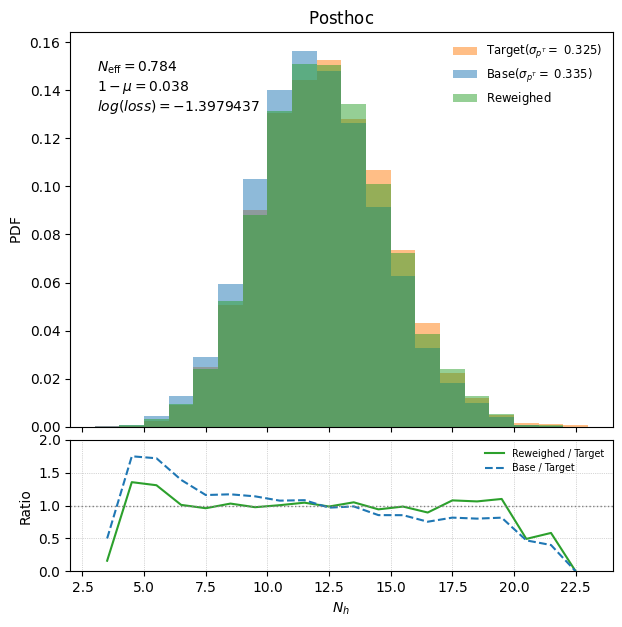

In [24]:
import matplotlib.pyplot as plt
import numpy as np

_, bins_target = np.histogram(mult_target)
_, bins_base = np.histogram(mult_base)

min_target, max_target = bins_target[0], bins_target[-1]
min_base, max_base = bins_base[0], bins_base[-1]

print(min_target, max_target)
#print(min_monash_prime, max_monash_prime)

min = np.min([min_target, min_base])
max = np.max([max_target, max_base])

bins = np.linspace(min, max, int((max - min)+1))

# Histogram binning and calculation
hist_target, _ = np.histogram(mult_target[0:Nevent], bins=bins, density=True)
hist_base, _ = np.histogram(mult_base[0:Nevent], bins=bins, density=True)
hist_reweighted, _ = np.histogram(mult_base[0:Nevent], bins=bins, weights=weights_loaded, density=True)

# Bin centers for plotting
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# --- Plot with Ratio subplot ---
fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, 
                                        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# --- Main Histogram Plot ---
ax_main.hist(mult_target[0:Nevent], bins=bins, alpha=0.5, 
             label=rf"$\mathrm{{Target}}$" + r"$(\sigma_{p^T} =$"+f" {sigma_alt})", 
             color='tab:orange', density=True)
ax_main.hist(mult_base[0:Nevent], bins=bins, alpha=0.5, 
             label=r'$\mathrm{Base}$' + r'$(\sigma_{p^T} =$'+f' {sigma})', 
             color='tab:blue', density=True)
ax_main.hist(mult_base[0:Nevent], bins=bins, weights=weights_loaded, alpha=0.5, 
             label=r"$\mathrm{Reweighed}$", color='tab:green', density=True)


wasserstein_loss = WassersteinLoss(p = 1)
z=torch.tensor(mult_base[0:Nevent])
w = torch.tensor(mult_target[0:Nevent])
weights = torch.tensor(weights_loaded)

print(type(z), type(w))
loss = wasserstein_loss(z,w,weights)
print(loss)

# Metrics Text
ax_main.text(0.05, 0.9, rf'$N_{{\mathrm{{eff}}}} = {Neff:.3f}$', fontsize=10, transform=ax_main.transAxes)
ax_main.text(0.05, 0.85, rf'$1 - \mu = {one_minus_mu:.3f}$', fontsize=10, transform=ax_main.transAxes)
ax_main.text(0.05, 0.8, rf'$log(loss) = {np.log10(loss):.7f}$', fontsize=10, transform=ax_main.transAxes)

# Axis Labels and Title
ax_main.set_ylabel(r'$\mathrm{PDF}$')
ax_main.legend(frameon=False, fontsize='small')
ax_main.set_title(r'$\mathrm{Posthoc}$')

# --- Ratio Plot ---
# Avoid divide-by-zero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_rw = np.divide(hist_reweighted, hist_target, out=np.zeros_like(hist_reweighted), where=hist_target != 0)
    ratio_base = np.divide(hist_base, hist_target, out=np.zeros_like(hist_base), where=hist_target != 0)

ax_ratio.plot(bin_centers, ratio_rw, color='tab:green', label='Reweighed / Target')
ax_ratio.plot(bin_centers, ratio_base, color='tab:blue', linestyle='--', label='Base / Target')
ax_ratio.axhline(1.0, color='gray', linestyle=':', linewidth=1)

ax_ratio.set_xlabel(r'$N_h$')
ax_ratio.set_ylabel('Ratio')
ax_ratio.set_ylim(0, 2)  # Adjust if needed
ax_ratio.legend(frameon=False, fontsize='x-small')
ax_ratio.grid(True, linestyle=':', linewidth=0.5)

# --- Final layout and save ---
fig.tight_layout()
plt.savefig('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/' + '3from0.335_t00.325.png')
plt.show()


In [48]:

wasserstein_loss = WassersteinLoss(p = 1)
z=torch.tensor(mult_base[0:Nevent])
w = torch.tensor(mult_target[0:Nevent])
weights = torch.tensor(weights_loaded)

print(type(z), type(w))
loss = wasserstein_loss(z,w,weights)
print(loss)


<class 'torch.Tensor'> <class 'torch.Tensor'>
tensor(1.0071, dtype=torch.float64)


[3. 1. 0. 1. 1. 0. 2. 2. 0. 1. 0. 1. 4. 2. 1. 0. 3. 5. 1. 3. 0. 2. 3. 3.
 0. 0. 1. 2. 3. 3. 1. 5. 1. 1. 2. 5. 1. 3. 2. 1. 0. 1. 1. 2. 1. 2. 1. 1.
 1. 1. 1. 3. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0.
 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1.]
[0.11703435 0.14244328 0.16785222 0.19326115 0.21867009 0.24407903
 0.26948796 0.2948969  0.32030583 0.34571477 0.3711237  0.39653264
 0.42194157 0.44735051 0.47275945 0.49816838 0.52357732 0.54898625
 0.57439519 0.59980412 0.62521306 0.650622   0.67603093 0.70143987
 0.7268488  0.75225774 0.77766667 0.80307561 0.82848454 0.85389348
 0.87930242 0.90471135 0.93012029 0.95552922 0.98093816 1.00634709
 1.03175603 1.05716496 1.0825739  1.10798284 1.13339177 1.15880071
 1.18420964 1.20961858 1.23502751 1.26043645 1.28584539 1.31125432
 1.33666326 1.36207219 1.38748113 1.41289006 1.438299   1.46370793
 1.48911687 1.51452581 1.53993474 1.56534368 1.59075261 1.61616155
 1.64157048 1.66697942 1

FileNotFoundError: [Errno 2] No such file or directory: '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/reweighting_sigma/from0.325_t00.335_weights.png'

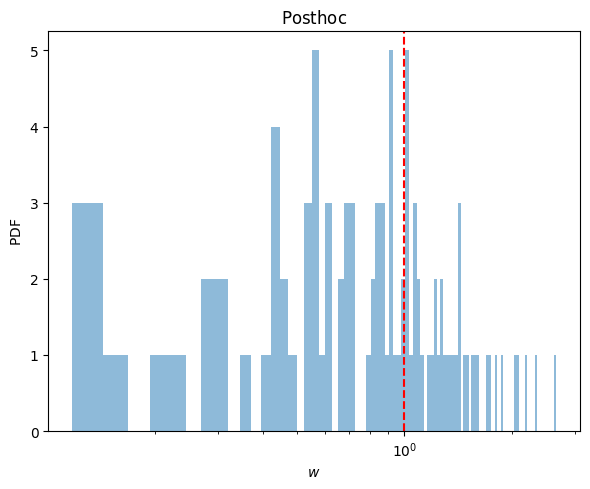

In [25]:
# Check the distribution of weights (Target v1)
fig, ax = plt.subplots(1,1,figsize=(6,5))
hists = ax.hist(weights[np.where(weights < 10)], 100, alpha = 0.5, density=False)
print(hists[0])
print(hists[1])
ax.set_xlabel(r'$w$')
ax.set_ylabel(r'$\mathrm{PDF}$')
ax.set_xscale('log')
ax.vlines(1., 0., 2., color = 'red', linestyle = '--', transform = ax.get_xaxis_transform())
ax.set_title(r'$\mathrm{Posthoc}$')
fig.tight_layout()
plt.savefig('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/reweighting_sigma/' + 'from0.325_t00.335_weights.png')




/tmp/ipykernel_1771245/584347179.py:42: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,1,figsize=(7,5))


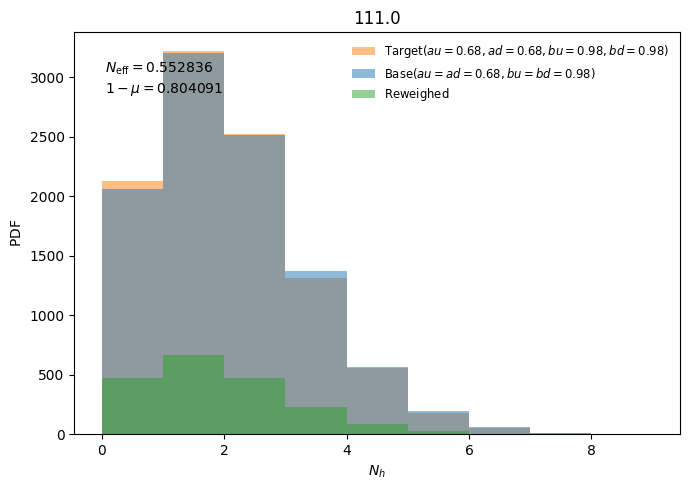

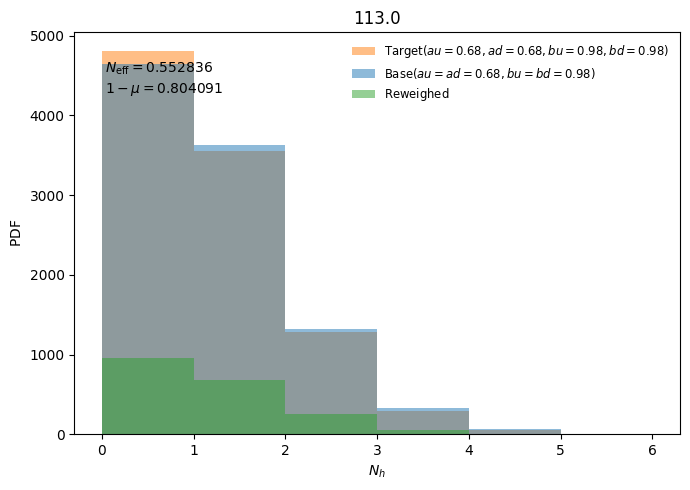

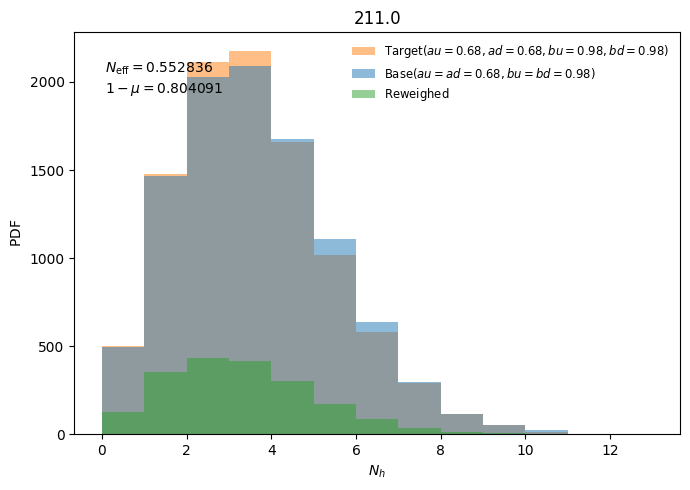

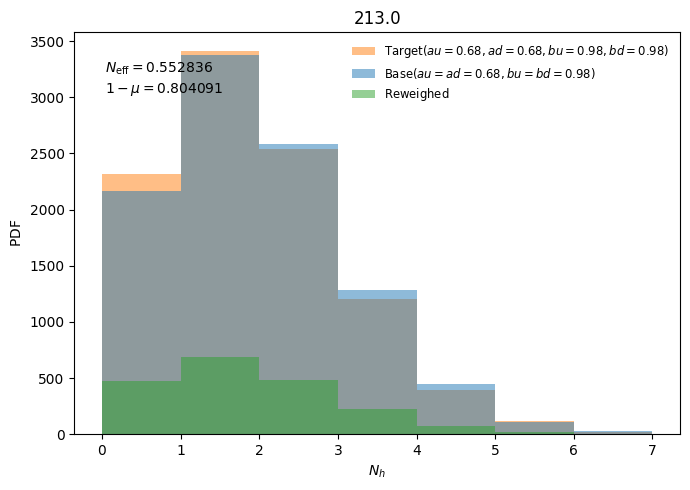

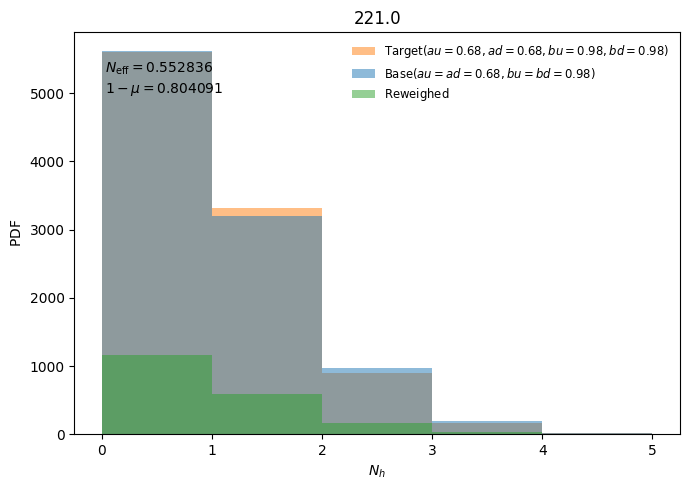

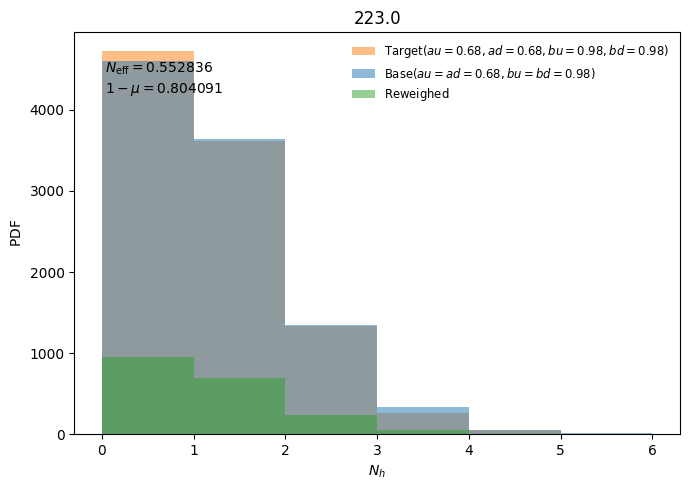

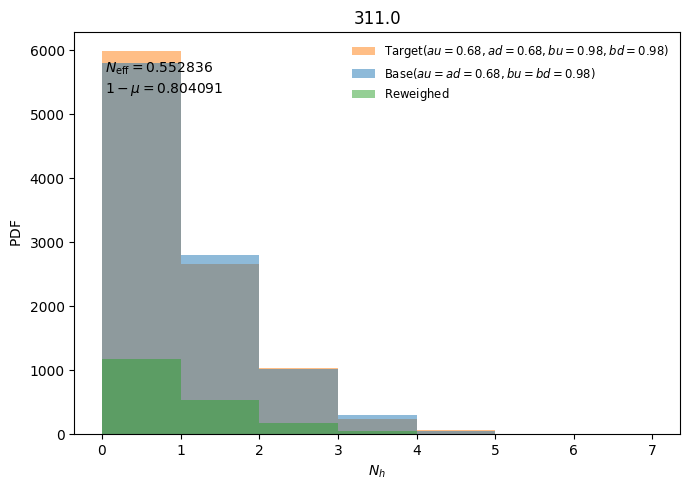

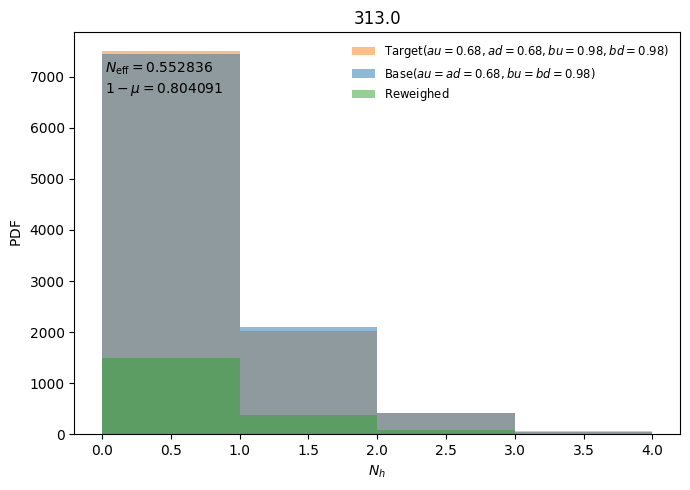

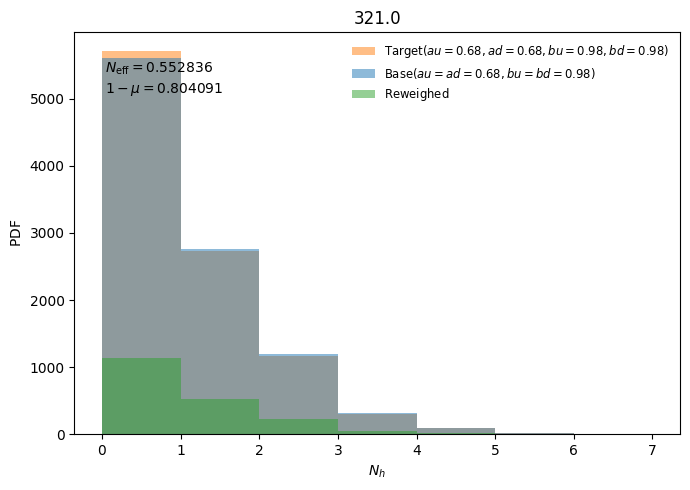

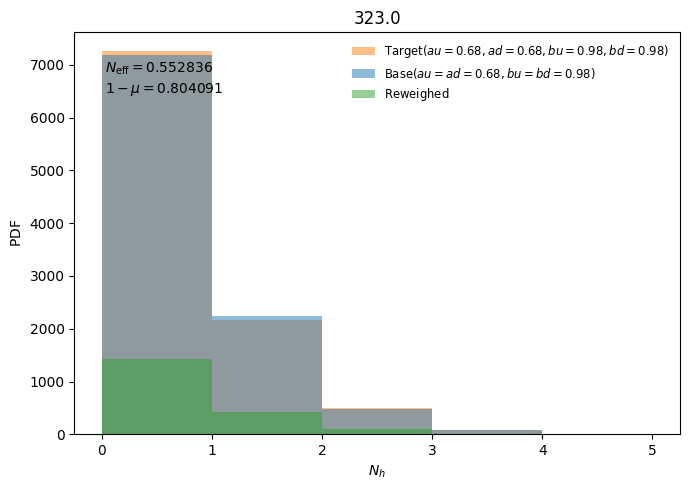

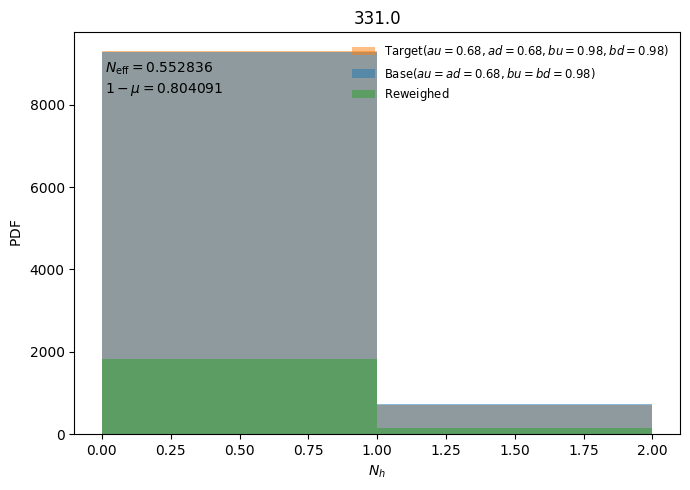

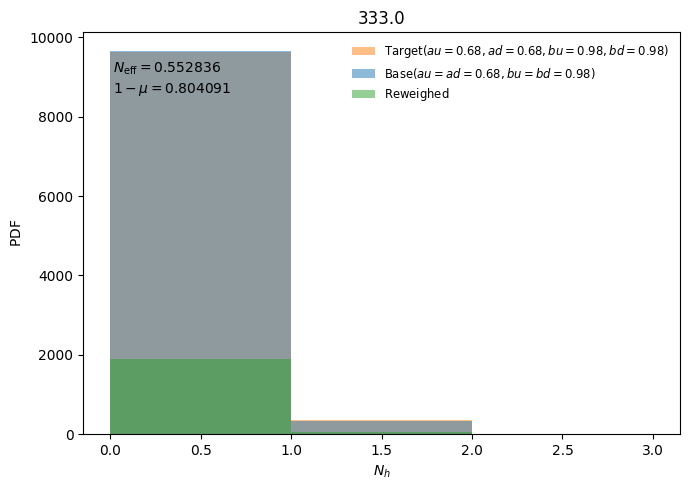

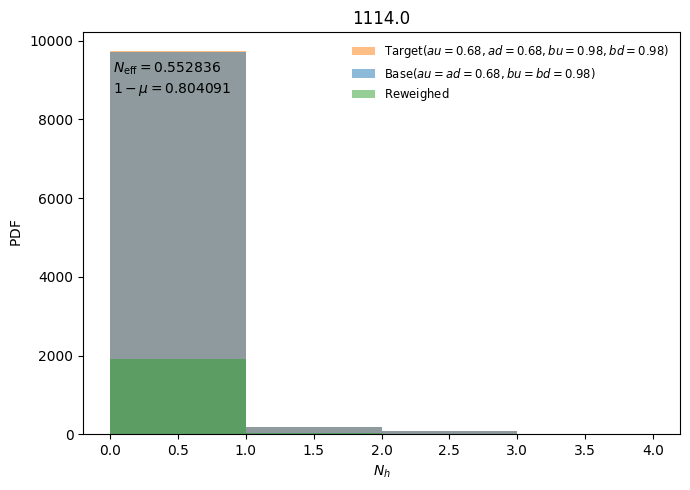

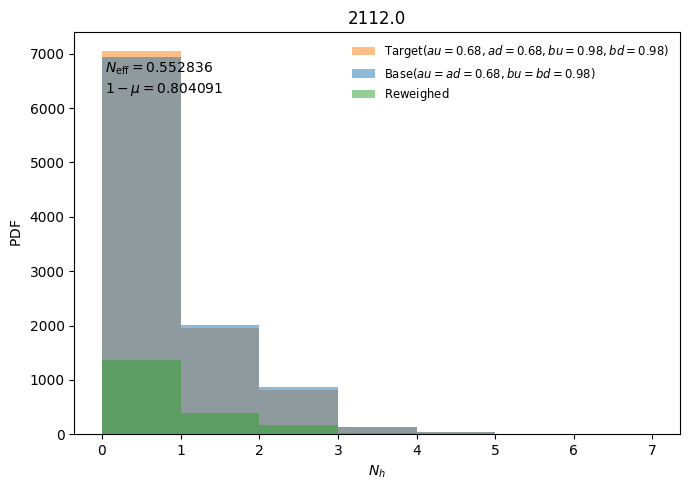

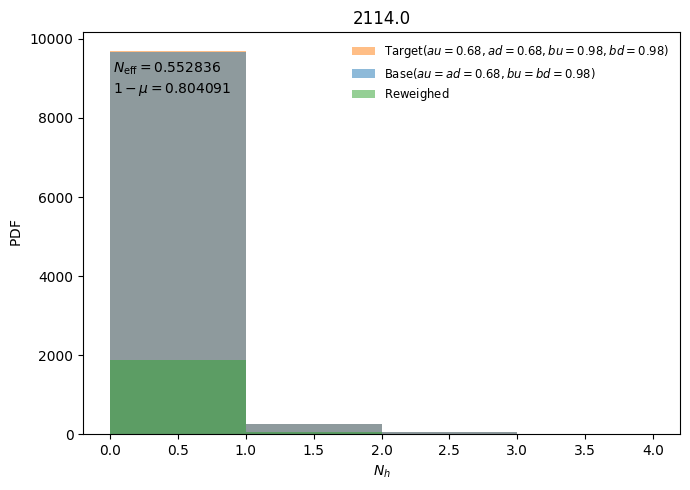

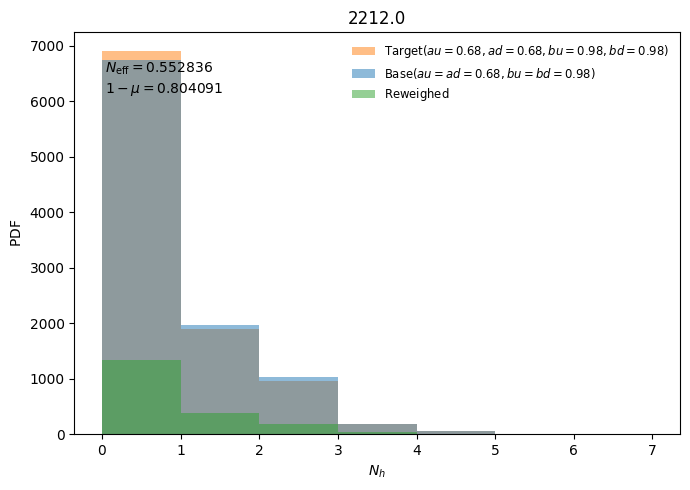

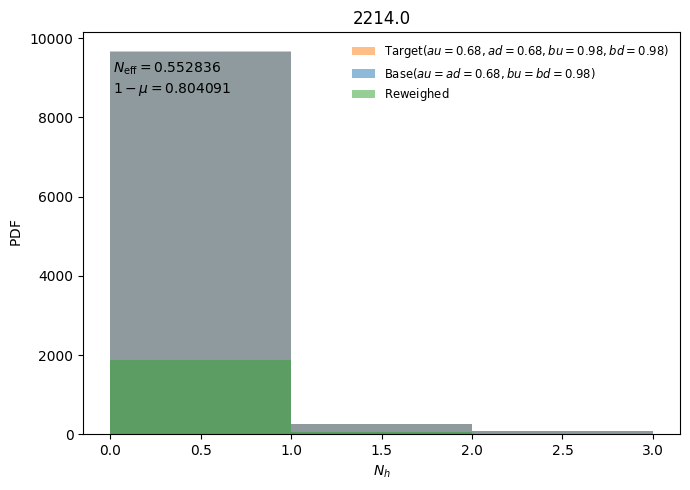

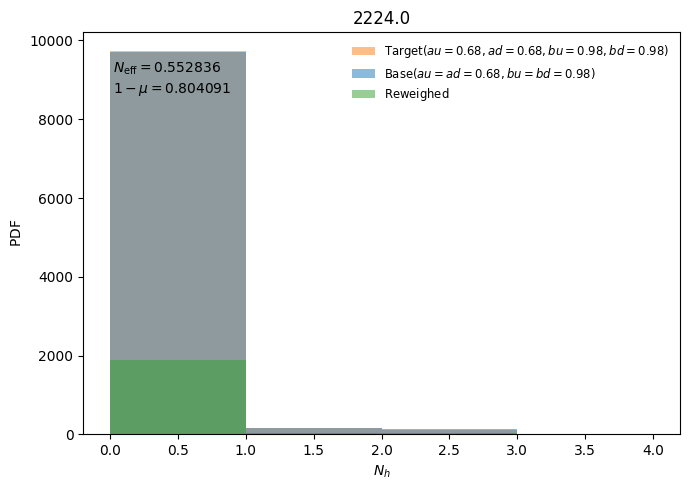

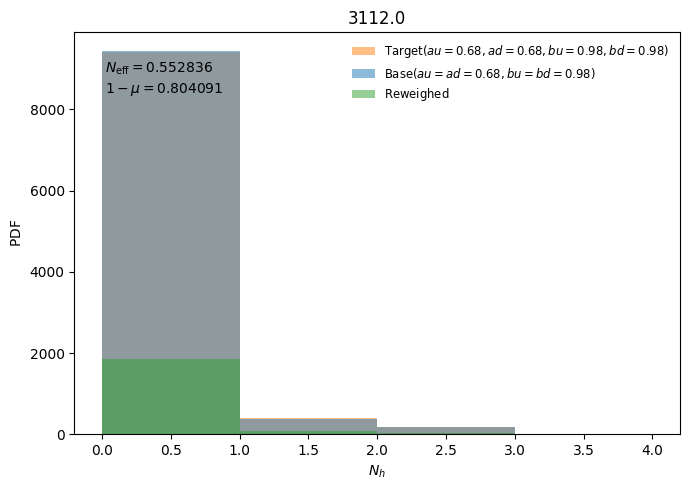

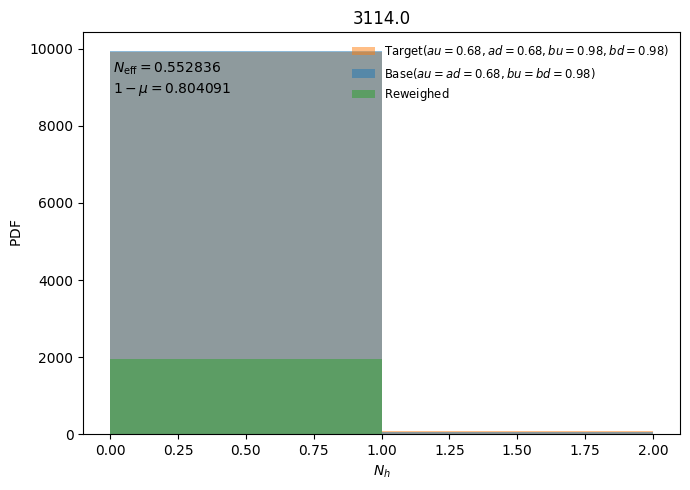

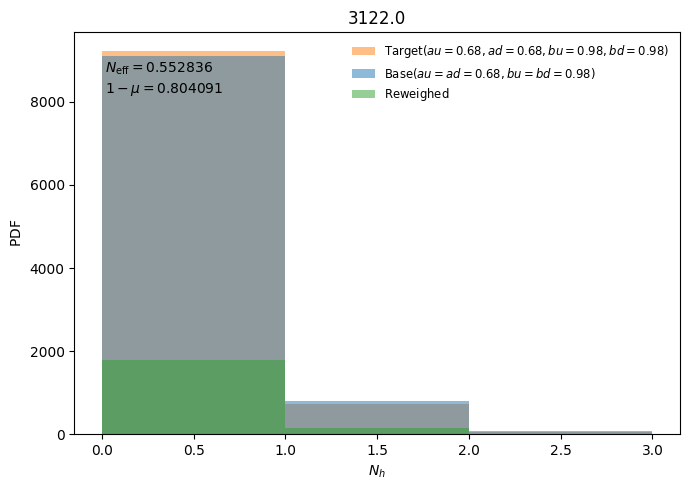

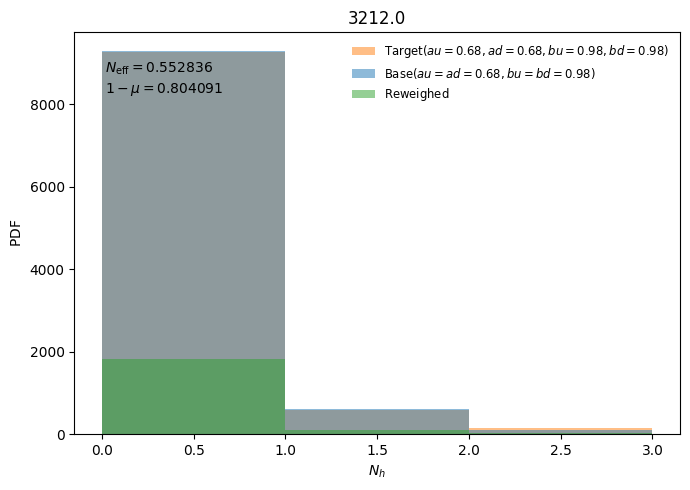

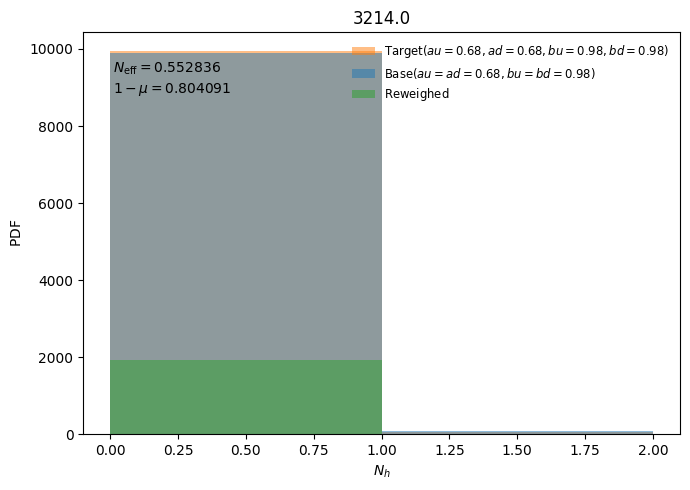

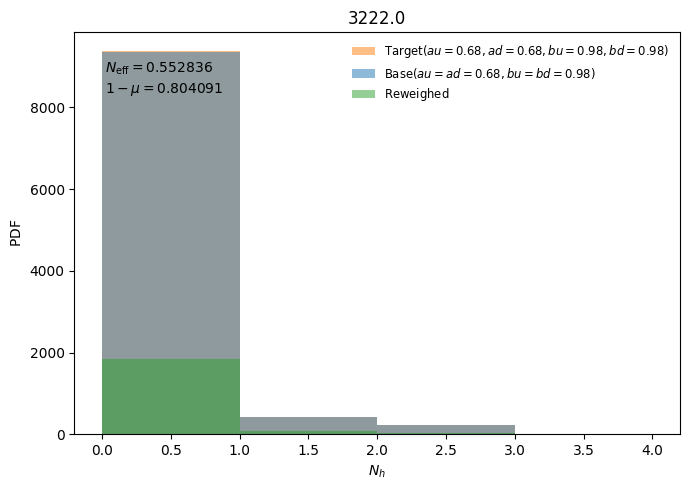

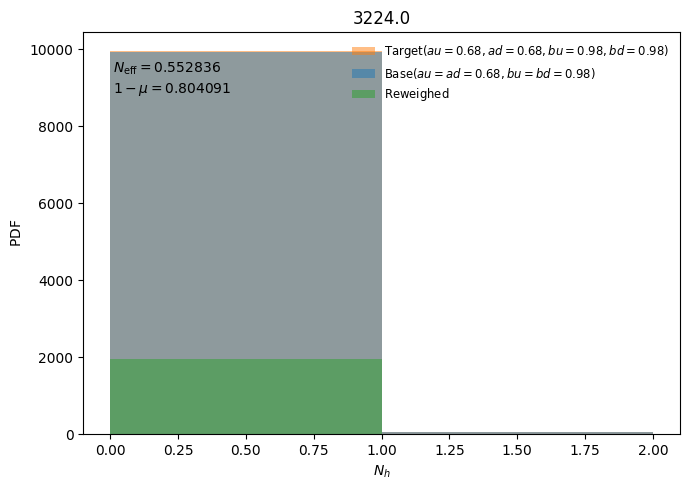

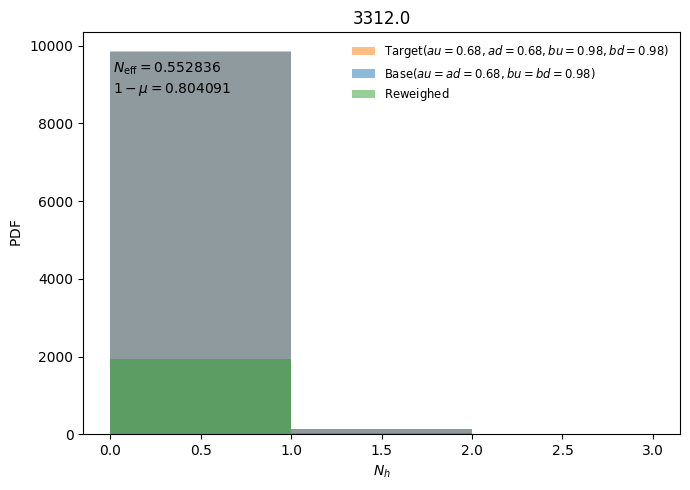

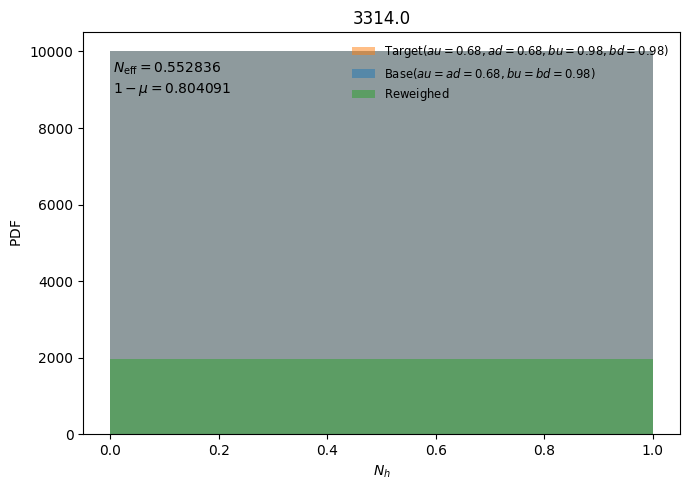

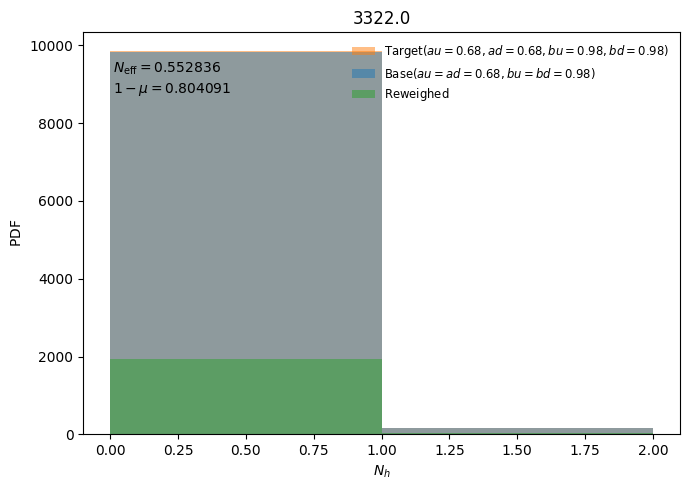

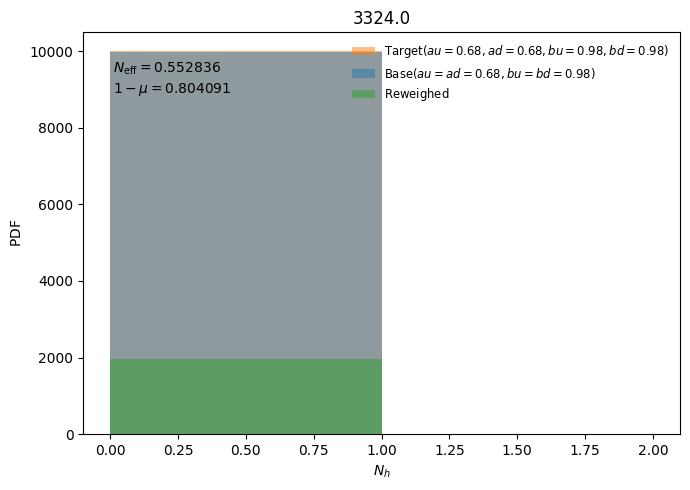

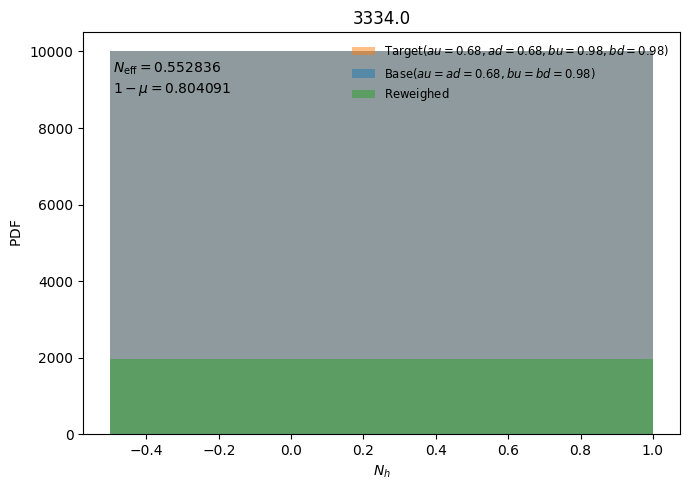

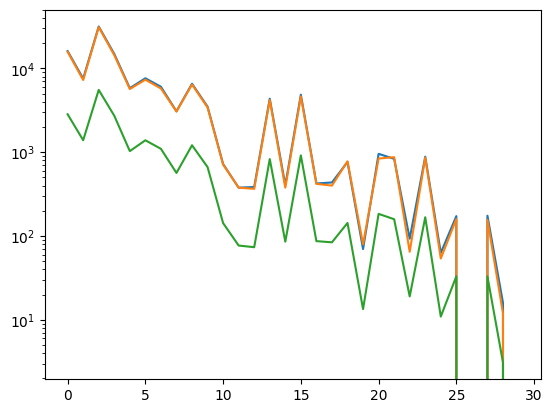

In [25]:
# with open("/pscratch/sd/l/ljpuslar/RSA/RSA/data/files/pythia_particles.json", "r") as f:
#     loaded_particles = json.load(f)

# ids_old = pgun_accept_reject_base[:,:,0][pgun_accept_reject_base[:,:,0] > 0.0]
# Nevent = 1000

ids_base = np.abs(pgun_hadrons_base[:,:,5][pgun_hadrons_base[:,:,0] > 0.0])
ids_target = np.abs(pgun_hadrons_target[:,:,5][pgun_hadrons_target[:,:,0] > 0.0])

ids = np.hstack([ids_base, ids_target])

particles, counts = np.unique(ids, return_counts=True)
len_par = len(particles)
# print(np.abs(pgun_hadrons_base[i,:,0]) > 0.0)
# print(np.abs(pgun_accept_reject_base[i,:,1]) == p)

b_particles = []
bw_particles = []
t_particles = []
for i,p in enumerate(particles):


    mult_base = np.array([len(pgun_hadrons_base[i,:][np.abs(pgun_hadrons_base[i,:,5]) == p]) for i in range(Nevent)])
    mult_target = np.array([len(pgun_hadrons_target[i,:][np.abs(pgun_hadrons_target[i,:,5]) == p]) for i in range(Nevent)])

    _, bins_target = np.histogram(mult_target)
    _, bins_base = np.histogram(mult_base)

    min_target, max_target = bins_target[0], bins_target[-1]
    min_base, max_base = bins_base[0], bins_base[-1]

    # print(min_target, max_target)
    #print(min_monash_prime, max_monash_prime)

    min = np.min([min_target, min_base])
    max = np.max([max_target, max_base])

    bins = np.linspace(min, max, int((max - min)+1))
    

    # Check the reweighed multiplicity historgram
    fig, ax = plt.subplots(1,1,figsize=(7,5))

    # ax.hist(mult_target[0:Nevent], bins = bins, alpha = 0.5, label = r"$\mathrm{Target}$"+ rf"$(au = {aLundU_alt:.}, ad = {aLundD_alt}, bu = {bLundU_alt}, bd = {bLundD_alt})$", color = 'tab:orange', density = True)
    t = ax.hist(mult_target[0:Nevent], bins=bins, alpha=0.5, 
            label=rf"$\mathrm{{Target}}$" + 
                rf"$(au = {aLundU_alt:.2f}, ad = {aLundD_alt:.2f}, " + 
                rf"bu = {bLundU_alt:.2f}, bd = {bLundD_alt:.2f})$", 
            color='tab:orange', density=False)
    b = ax.hist(mult_base[0:Nevent], bins = bins, alpha = 0.5, label = r'$\mathrm{Base}$' + rf'$(au = ad = {aLund}, bu = bd = {bLund})$', color = 'tab:blue', density = False)
    bw = ax.hist(mult_base[0:Nevent], bins = bins, weights = weights_loaded, alpha = 0.5, label = r"$\mathrm{Reweighed}$", color = 'tab:green', density = False)

    t,b,bw = t[0],b[0],bw[0]
    # ax.errorbar(bin_centers_target, hist_vals_target, yerr=errors_target, fmt=".", color="black", label="Error Bars")

    bins_calc = bins[:-1]
    b_particles.append(np.sum(b * bins_calc))
    bw_particles.append(np.sum(bw * bins_calc))
    t_particles.append(np.sum(t * bins_calc))
    # Place the rewighting metrics on the upper left corner of the figure
    ax.text(0.05, 0.9, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10, transform = ax.transAxes)
    ax.text(0.05, 0.85, rf'$1 - \mu = {one_minus_mu:3f}$', fontsize = 10, transform = ax.transAxes)

    #ax.text(1.0, 0.10, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10)
    #ax.text(1.0, 0.10, rf'$N_{{\mathrm{{eff}}}} = {Neff:3f}$', fontsize = 10)
    #ax.text(1.0, 0.095, rf'$1 - \mu = {one_minus_mu:3f}$', fontsize = 10)

    ax.set_xlabel(r'$N_h$')
    ax.set_ylabel(r'$\mathrm{PDF}$')
    ax.legend(frameon = False, fontsize = 'small')
    ax.set_title(r'$\mathrm{Posthoc}$')
    ax.set_title(f'{p}')
    fig.tight_layout()

plt.figure()
plt.plot(b_particles)
plt.plot(t_particles)
plt.plot(bw_particles)
plt.yscale('log')
